# SMO Studio — Black-Box Applet

Black-box companion to the white-box capstone. Contains only the **core function definitions** (identical to the white-box notebook) and **Section 10 — the SMO Studio applet**.

Run all core cells once, top to bottom, then use the applet at the end.

**Backend:** auto-detects a GPU (CuPy) and falls back to CPU (NumPy) — no edit needed.

**Applet flow:** pick reticle + resolution + starting DOE → run the full 9-DOE SMO sweep → re-run the winning DOE **with and without freeform** → lower-loss run wins → export a timestamped PDF dashboard.

## Core definitions
_Identical to the white-box notebook._

In [1]:
# --- Backend selection -------------------------------------------------------
# To move to GPU later, change this one block. Nothing else should import numpy.
import numpy as _np

# Black-box: auto-detect GPU (cupy); fall back to CPU (numpy).
try:
    import cupy as _probe   # noqa
    BACKEND = "cupy"
except Exception:
    BACKEND = "numpy"

if BACKEND == "numpy":
    import numpy as xp
    def to_cpu(a):           # bring an xp array back to host numpy for plotting
        return _np.asarray(a)
elif BACKEND == "cupy":
    import cupy as xp                      # noqa
    def to_cpu(a):
        return xp.asnumpy(a)
elif BACKEND == "jax":
    import jax.numpy as xp                 # noqa
    def to_cpu(a):
        return _np.asarray(a)
else:
    raise ValueError(BACKEND)

import matplotlib.pyplot as plt
print(f"Backend = {BACKEND}, xp = {xp.__name__}")


CDTYPE = xp.complex64    # global complex precision
RDTYPE = xp.float32      # matching real dtype

Backend = cupy, xp = cupy


In [2]:
# @title 1.2 Physical constants & global grid (SET MASK RESOLUTION HERE)
from dataclasses import dataclass, replace

# --- ArF system constants (idealized, all SI / metres) ----------------------
WAVELENGTH    = 193e-9    # m   ArF excimer line
M_REDUCTION   = 4         # reticle is 4x larger than wafer (UNCHANGED by immersion)

# --- Dry vs IMMERSION DUV ----------------------------------------------------
# Immersion (193i) floods water (n~1.44 @193nm) between the last lens element
# and the wafer, raising the achievable NA above the dry ceiling (~1.0). Higher
# NA => more diffraction orders captured => smaller wafer CD (CD ~ k1*lambda/NA).
# The reduction ratio M is UNCHANGED (still 4x); only NA (and thus wafer CD)
# changes. Reticle CD = wafer CD * M tracks down in proportion.
IMMERSION     = False     # <-- checkbox: False = dry ArF, True = 193i immersion

NA_DRY        = 0.85      # operating projection NA, dry ArF
NA_IMMERSION  = 1.35      # operating projection NA, 193i immersion (production)
NA_MAX_DRY    = 0.93      # hardware ceiling for a DRY ArF lens
NA_MAX_IMM    = 1.35      # hardware ceiling with water immersion
N_IMMERSION   = 1.44      # refractive index of water at 193 nm (for reference)

# Grating pitch (demo target) authored at the WAFER. Immersion resolves finer
# pitch, so we shrink the demo CD to an immersion-realistic value when enabled.
GRATING_PITCH_DRY = 250e-9   # m   wafer pitch, dry ArF demo
GRATING_PITCH_IMM = 130e-9   # m   wafer pitch, immersion demo (finer, ~half-pitch 65nm)

# Resolve the immersion-dependent operating point:
NA            = NA_IMMERSION if IMMERSION else NA_DRY
NA_MAX        = NA_MAX_IMM   if IMMERSION else NA_MAX_DRY
GRATING_PITCH = GRATING_PITCH_IMM if IMMERSION else GRATING_PITCH_DRY

# --- Sampling resolution (numerical knob — does NOT change the physical scene)
# N only controls how finely we sample. Raising it = smoother FFTs + more
# padding, NOT more diffraction orders inside the NA. Whether grating order m is
# collected is the physical condition m/pitch <= NA/lambda — independent of N.
RESOLUTION = "final"                                    # "fast"|"normal"|"final"
N = {"fast": 512, "normal": 1024, "final": 2048}[RESOLUTION]

# --- Physical scene (authored in metres — independent of N) ------------------
# Immersion resolves finer pitch, so shrink the FOV too so the finer grating
# still spans a sensible number of pixels (keeps the demo legible at fixed N).
FOV_WAFER     = 2e-6 if IMMERSION else 4e-6   # m   field of view at the wafer

# --- Derived sampling (pixels are derived, never authored) -------------------
dx_wafer   = FOV_WAFER / N
dx_reticle = dx_wafer * M_REDUCTION          # reticle features are M x larger

# Pupil radius: lens passes spatial frequencies up to NA/lambda.
df_wafer        = 1.0 / (N * dx_wafer)       # = 1 / FOV_WAFER
pupil_radius_px = (NA / WAVELENGTH) / df_wafer

# --- Sanity / physical bounds ------------------------------------------------
assert NA <= NA_MAX, f"NA={NA} exceeds {'immersion' if IMMERSION else 'dry-ArF'} hardware max {NA_MAX}"
assert pupil_radius_px < N//2, "Pupil overfills grid — raise N or shrink FOV_WAFER."

print(f"MODE            = {'IMMERSION 193i (n=%.2f)' % N_IMMERSION if IMMERSION else 'DRY ArF'}")
print(f"NA              = {NA:.2f}  (max {NA_MAX:.2f})")
print(f"M_REDUCTION     = {M_REDUCTION}x   (reticle CD = wafer CD x {M_REDUCTION}, unchanged by immersion)")
print(f"RESOLUTION      = {RESOLUTION} (N={N})")
print(f"dx_wafer        = {dx_wafer*1e9:.3f} nm/pixel")
print(f"dx_reticle      = {dx_reticle*1e9:.3f} nm/pixel")
print(f"grating pitch   = {GRATING_PITCH*1e9:.1f} nm wafer  ({GRATING_PITCH/dx_wafer:.1f} px at wafer)")
print(f"  -> reticle    = {GRATING_PITCH*M_REDUCTION*1e9:.1f} nm at the reticle plane")
print(f"pupil radius    = {pupil_radius_px:.1f} px (of {N//2} max)")
print(f"Rayleigh k1=0.5 half-pitch (wafer CD) = {0.5*WAVELENGTH/NA*1e9:.1f} nm")


MODE            = DRY ArF
NA              = 0.85  (max 0.93)
M_REDUCTION     = 4x   (reticle CD = wafer CD x 4, unchanged by immersion)
RESOLUTION      = final (N=2048)
dx_wafer        = 1.953 nm/pixel
dx_reticle      = 7.812 nm/pixel
grating pitch   = 250.0 nm wafer  (128.0 px at wafer)
  -> reticle    = 1000.0 nm at the reticle plane
pupil radius    = 17.6 px (of 1024 max)
Rayleigh k1=0.5 half-pitch (wafer CD) = 113.5 nm


In [3]:
# @title 2.4 The Field container & FFT/IFFT transforms
# source = array of shape (P, 3): rows of (kx, ky, weight)
#   kx, ky : source-point position in PUPIL coordinates, normalized so the
#            projection-NA edge = 1.0  (so kx²+ky² = σ² for a point at radius σ)
#   weight : relative intensity of that point (enables graded/apodized fills + SMO)
# σ-constructors (conventional/annular/dipole) EMIT this object.
# A free-form DOE / SMO writes this object directly. Same type either way.


@dataclass
class Field:
    data: object        # complex array (xp), shape (N, N)
    dx: float           # real-space sampling, metres
    wavelength: float   # metres
    domain: str         # 'real' | 'pupil'

    def copy_with(self, **kw):
        return replace(self, **kw)

# --- Centralised FFT helpers (the ONLY fft calls in the codebase) -----------
def to_pupil(f):
    "Real space -> pupil (far field). Centred, unitary."
    assert f.domain == "real", f"to_pupil expects real, got {f.domain}"
    spec = xp.fft.fftshift(xp.fft.fft2(xp.fft.ifftshift(f.data), norm="ortho"))
    return f.copy_with(data=spec, domain="pupil")

def to_real(f):
    "Pupil -> real space. Inverse of to_pupil."
    assert f.domain == "pupil", f"to_real expects pupil, got {f.domain}"
    img = xp.fft.fftshift(xp.fft.ifft2(xp.fft.ifftshift(f.data), norm="ortho"))
    return f.copy_with(data=img, domain="real")

def intensity(f):
    "|E|^2 as host numpy, for measurement/plotting."
    return to_cpu(xp.abs(f.data)**2)

In [4]:
# @title 3.5 Visualisation helpers
def show_field(f, title="", log_amp=False):
    "Plot amplitude/intensity and phase of a complex Field."
    a = to_cpu(xp.abs(f.data))
    p = to_cpu(xp.angle(f.data))
    amp = _np.log10(a + a.max()*1e-6 + 1e-12) if log_amp else a

    fig, ax = plt.subplots(1, 2, figsize=(10, 4.2))
    im0 = ax[0].imshow(amp, cmap="inferno")
    ax[0].set_title(f"{title}  |  {'log amplitude' if log_amp else 'amplitude'}  ({f.domain})")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(p, cmap="twilight", vmin=-_np.pi, vmax=_np.pi)
    ax[1].set_title(f"{title}  |  phase (rad)")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)
    for a_ in ax:
        a_.set_xticks([]); a_.set_yticks([])
    plt.tight_layout(); plt.show()

def show_intensity(f, title="", extent_um=None):
    "Single intensity panel — used for the wafer plane."
    I = intensity(f)
    plt.figure(figsize=(5.2, 4.6))
    ext = None
    if extent_um is not None:
        ext = [-extent_um/2, extent_um/2, -extent_um/2, extent_um/2]
    plt.imshow(I, cmap="viridis", extent=ext)
    plt.title(title)
    plt.colorbar(fraction=0.046, label="intensity (a.u.)")
    if ext:
        plt.xlabel("µm"); plt.ylabel("µm")
    plt.tight_layout(); plt.show()

def show_source_pupil(src, title="Effective source (DOE pupil)",
                      bins=None, interp="nearest", cmap="inferno"):
    """Render a source as a continuous pupil INTENSITY MAP (not a scatter).
    Bins the (kx, ky, weight) points onto a pupil grid and shows it as an image.
    Works for any source — parametric σ-shapes or a free-form / SMO-designed DOE.

    bins   : pupil-grid resolution for display. None = infer from the source's
             own sampling (one bin per source point ≈ faithful). Raise for a
             smoother display ONLY if the source itself is finely sampled.
    interp : imshow interpolation. 'nearest' (default) shows one solid square
             per source point — HONEST for a binary aperture where every "on"
             point has the same weight. 'gaussian' or 'bilinear' smooth
             between bins and INVENT intermediate brightness that isn't
             actually there — a binary source rendered with 'gaussian' looks
             like a smooth "flame" of varying intensity, which will mislead
             anyone reading the plot. Only use smoothing when the source is
             genuinely multi-level (mirror-array, source_levels ≥ 5).
    """
    kx, ky, w = src[:, 0], src[:, 1], src[:, 2]
    if bins is None:
        ukx = _np.unique(_np.round(kx, 6))
        if len(ukx) > 1:
            pitch = _np.min(_np.diff(ukx))
            bins = int(round(2.0 / pitch)) + 1
        else:
            bins = 64
    edges = _np.linspace(-1.0, 1.0, bins + 1)
    img, _, _ = _np.histogram2d(ky, kx, bins=[edges, edges], weights=w)  # row=ky
    plt.figure(figsize=(5.0, 4.6))
    plt.imshow(img, extent=[-1, 1, -1, 1], origin="lower",
               cmap=cmap, interpolation=interp)
    th = _np.linspace(0, 2 * _np.pi, 200)
    plt.plot(_np.cos(th), _np.sin(th), "c--", lw=1.5, label="NA edge (σ=1)")
    plt.gca().set_aspect("equal"); plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
    plt.title(f"{title}  ({len(src)} pts, {bins}×{bins} grid)")
    plt.xlabel("kx (σ)"); plt.ylabel("ky (σ)"); plt.legend(loc="upper right")
    plt.colorbar(fraction=0.046, label="power fraction"); plt.tight_layout(); plt.show()

def show_source_pupil_ax(src, ax, title="DOE AFTER  (designed source)",
                         bins=None, interp="nearest", cmap="inferno",
                         add_colorbar=True):
    """Rasterized DOE pupil image drawn INTO an existing axis `ax`
    (for use inside a multi-panel figure). Mirrors show_source_pupil but
    does not create or show its own figure."""
    kx, ky, w = src[:, 0], src[:, 1], src[:, 2]
    if bins is None:
        ukx = _np.unique(_np.round(kx, 6))
        bins = int(round(2.0/_np.min(_np.diff(ukx)))) + 1 if len(ukx) > 1 else 64
    edges = _np.linspace(-1.0, 1.0, bins + 1)
    img, _, _ = _np.histogram2d(ky, kx, bins=[edges, edges], weights=w)  # row=ky
    im = ax.imshow(img, extent=[-1, 1, -1, 1], origin="lower",
                   cmap=cmap, interpolation=interp)
    th = _np.linspace(0, 2*_np.pi, 200)
    ax.plot(_np.cos(th), _np.sin(th), "c--", lw=1.5)
    ax.set_aspect("equal"); ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    ax.set_title(f"{title}  ({len(src)} pts, {bins}×{bins})")
    ax.set_xlabel("kx (σ)"); ax.set_ylabel("ky (σ)")
    if add_colorbar:
        import matplotlib.pyplot as _plt
        _plt.colorbar(im, ax=ax, fraction=0.046, label="power fraction")
    return im

In [5]:
# --- Targets and error metrics for optimization ------------------------------
# The target is the pattern we WANT printed at the wafer (binary, 1 = resist).
# We build it from the same reticle library: the "ideal" printed result is just
# the mask pattern itself (what we'd get from a perfect, aberration-free system).
#
# Two error measures:
#   pattern_error  : mean-squared difference between printed and target (the loss
#                    SMO minimizes; smooth, differentiable).
#   edge_error     : an EPE-like proxy = total area mismatch along edges, in
#                    pixels^2, for human-readable "how far off" reporting.

def make_target(name):
    """Target printed pattern (binary, host numpy) for a library reticle name.
    The ideal print equals the drawn mask geometry."""
    m = make_reticle(name)
    return (to_cpu(xp.abs(m)) > 0.5).astype(_np.float64)

def pattern_error(printed, target):
    "Mean-squared pattern error (the differentiable SMO loss)."
    d = printed - target
    return float(_np.mean(d * d))

def edge_error_px(printed, target, level=0.5):
    "Area mismatch (XOR) between thresholded print and target, in pixels."
    p = (printed >= level).astype(_np.float64)
    return float(_np.sum(_np.abs(p - target)))

def show_compare(target, printed_before, printed_after, title=""):
    "Three-panel: target | printed before SMO | printed after SMO."
    fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.6))
    for a_, img, t in zip(
        ax, [target, printed_before, printed_after],
        ["Target (desired print)", "Printed BEFORE SMO", "Printed AFTER SMO"]):
        im = a_.imshow(img, cmap="gray_r", vmin=0, vmax=1)
        a_.set_title(t); a_.set_xticks([]); a_.set_yticks([])
    eb = edge_error_px(printed_before, target)
    ea = edge_error_px(printed_after,  target)
    plt.suptitle(f"{title}   edge mismatch: {eb:.0f}px → {ea:.0f}px "
                 f"({100*(eb-ea)/max(eb,1):.0f}% better)", y=1.02)
    plt.tight_layout(); plt.show()

In [6]:
def make_source_field():
    "Ideal cabinet output: uniform amplitude, flat phase, at the reticle plane."
    data = xp.ones((N, N), dtype=CDTYPE)   # unit amplitude, zero phase
    return Field(data=data, dx=dx_reticle, wavelength=WAVELENGTH, domain="real")

In [7]:
# @title 5.1.1 Stage 1: Illuminator
# --- Stage 1: Illuminator ----------------------------------------------------
# Applies ONE source point as a tilt (a linear phase ramp across the field).
# The SET of source points lives in the `source` object (see source constructors);
# forward() iterates the set and calls this once per point. Keeping the loop in
# forward() — not here — is what keeps this stage pure and SMO-ready.
#
# Convention: (kx, ky) are in pupil coordinates normalized so the projection-NA
# edge = 1.0. A point at radius sigma therefore satisfies kx^2 + ky^2 = sigma^2.
# The matching spatial frequency AT THE RETICLE PLANE is (NA/(M*lambda))*(kx,ky):
# an M x reduction system demagnifies the illumination cone to NA/M on the mask
# side. After the lens's x M demagnification these tilts correspond to
# (NA/lambda)*(kx,ky) at the wafer — which is what the pupil bookkeeping uses.

# Precompute real-space coordinate axes once (metres), centred on the grid.
_coord = (xp.arange(N) - N // 2) * dx_reticle          # 1-D axis, metres
_YY, _XX = xp.meshgrid(_coord, _coord, indexing="ij")  # 2-D real-space coords

def illuminator(f, kx=0.0, ky=0.0, params=None):
    """Tilt the incident plane wave by one source point (kx, ky).

    kx, ky : this source point's position in pupil coords (NA edge = 1.0).
             (0, 0) = on-axis = no tilt (ideal flat-top pass-through).
    params : reserved (polarization, etc.); schema TBD, unused for now.

    A tilted plane wave is exp(i 2pi (fx x + fy y)) with spatial frequency
    (fx, fy) = (NA/(M*lambda)) * (kx, ky) at the reticle plane (the mask-side
    illumination NA is NA/M). xp-clean: pure functional phase ramp, no
    in-place mutation, so it traces under JAX autodiff.
    """
    assert f.domain == "real"
    if kx == 0.0 and ky == 0.0:
        return f.copy_with(data=f.data * 1.0)          # on-axis: untouched
    # FIX(#1): _coord is built from dx_reticle, so the ramp must use the
    # RETICLE-side frequency NA/(M*lambda) — not the wafer-side NA/lambda.
    # The old value made every tilt M x too steep (sigma_eff = M*sigma): a
    # kx=1 point shifted the spectrum ~4 pupil radii instead of exactly 1,
    # so any source point with sigma > 1/M = 0.25 threw its 0th order
    # outside the pupil, corrupting every partially-coherent result.
    fx = (NA / (M_REDUCTION * WAVELENGTH)) * kx
    fy = (NA / (M_REDUCTION * WAVELENGTH)) * ky
    ramp = xp.exp(2j * xp.pi * (fx * _XX + fy * _YY))
    return f.copy_with(data=f.data * ramp)

In [8]:
# @title 5.2.1 Stage 2: Reticle (mask)

# --- Stage 2: Reticle (mask) ------------------------------------------------
def make_demo_mask():
    """Binary amplitude grating, pitch = GRATING_PITCH (defined at the wafer).
    The mask lives at the reticle plane, so the pitch in mask pixels uses
    dx_reticle. Built from the physical pitch — never a hardcoded pixel count —
    so it stays 250 nm regardless of N."""
    # pitch in reticle-plane pixels: wafer pitch scaled up by M, then / dx_reticle
    period_px = (GRATING_PITCH * M_REDUCTION) / dx_reticle      # = GRATING_PITCH/dx_wafer
    period_px = int(round(period_px))
    duty_px   = period_px // 2                                  # 1:1 lines:spaces

    m = xp.zeros((N, N), dtype=CDTYPE)
    c = N // 2
    half = N // 4                                              # patterned window half-width
    cols = xp.arange(N)
    line = ((cols % period_px) < duty_px)
    m[c-half:c+half, :] = line[None, :].astype(CDTYPE)
    m[:, :c-half] = 0; m[:, c+half:] = 0                       # restrict to central window
    return m

def reticle(f, mask):
    "Thin binary mask: multiply field by transmission. Diffraction begins here."
    assert f.domain == "real"
    assert mask.shape == f.data.shape
    return f.copy_with(data=f.data * mask)

In [9]:
# @title 5.3.1 Stage 3: Projection lens (NA-limited imaging)
# --- Stage 3: Projection lens (NA-limited imaging) --------------------------
def _pupil_mask(radius_px):
    yy, xx = xp.meshgrid(xp.arange(N) - N//2, xp.arange(N) - N//2, indexing="ij")
    rr = xp.sqrt(xx**2 + yy**2)
    return (rr <= radius_px).astype(RDTYPE)

PUPIL = _pupil_mask(pupil_radius_px)

def projection_lens(f, pupil=None):
    "Diffraction-limited imaging: FT -> clip by NA pupil -> inverse FT."
    assert f.domain == "real"
    if pupil is None:
        pupil = PUPIL
    spec = to_pupil(f)                                 # diffraction spectrum
    spec = spec.copy_with(data=spec.data * pupil)      # NA low-pass filter
    img  = to_real(spec)                               # complex aerial image
    return img



In [10]:
# --- Stage 4: Wafer (CAR resist) --------------------------------------------
# NOTE: the REAL resist threshold model (sigmoid dose-to-clear) is defined in
# §8 (Resist & SMO), because it needs forward() and the dose normalization. This
# placeholder keeps the per-stage walkthrough runnable; §8 overrides wafer().


def wafer(f, threshold=None):
    """Placeholder: returns the field so the per-stage view can show |E|^2.
    Overridden in §8 by the sigmoid resist model that maps intensity -> print."""
    assert f.domain == "real"
    return f

In [11]:
# @title 5a.3 Standard DOEs
# --- Effective source constructors -------------------------------------------
# The source is a free-form object: an array of shape (P, 3), rows (kx, ky, w).
#   kx, ky : pupil coords, NA edge = 1.0  (so radius = partial-coherence sigma)
#   w      : relative weight (uniform here; graded fills + SMO write w directly)
# Parametric sigma-shapes below are CONVENIENCE CONSTRUCTORS that emit this same
# object. A free-form DOE / SMO writes the (P,3) array directly — identical type,
# so forward() never needs to know how the source was made.
#
# Implementation note: we lay a square grid over the pupil, keep only points
# whose (kx,ky) fall inside the requested shape. `n` sets sampling density of the
# source — too few -> grainy/dose error, too many -> slow. Converge by refining.

def _source_grid(n):
    "Square grid of candidate (kx, ky) points spanning the unit pupil [-1,1]^2."
    g = _np.linspace(-1.0, 1.0, n)
    KX, KY = _np.meshgrid(g, g)
    return KX.ravel(), KY.ravel()

def _emit(KX, KY, keep):
    "Pack kept points into the (P,3) source object with uniform weights."
    kx, ky = KX[keep], KY[keep]
    w = _np.ones_like(kx)
    src = _np.stack([kx, ky, w], axis=1)
    src[:, 2] /= src[:, 2].sum()            # normalize weights to sum = 1
    return src

def conventional(sigma=0.7, n=21):
    "Disk source of radius sigma (partial coherence)."
    KX, KY = _source_grid(n)
    keep = (KX**2 + KY**2) <= sigma**2
    return _emit(KX, KY, keep)

def annular(sigma_in=0.5, sigma_out=0.8, n=21):
    "Annular source between sigma_in and sigma_out."
    KX, KY = _source_grid(n)
    r2 = KX**2 + KY**2
    keep = (r2 >= sigma_in**2) & (r2 <= sigma_out**2)
    return _emit(KX, KY, keep)

def dipole(sigma_c=0.7, sigma_r=0.2, angle_deg=0.0, n=21):
    "Two poles centred at radius sigma_c, each of radius sigma_r, along `angle`."
    KX, KY = _source_grid(n)
    a = _np.deg2rad(angle_deg)
    cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
    d1 = (KX - cx)**2 + (KY - cy)**2
    d2 = (KX + cx)**2 + (KY + cy)**2
    keep = (d1 <= sigma_r**2) | (d2 <= sigma_r**2)
    return _emit(KX, KY, keep)


# --- Additional pupil shapes (v10) -------------------------------------------
# All share the (P,3) source format. All take an `n` grid-sampling argument.
# Same convergence guidance as the originals: n too low = coarse/grainy, n
# too high = slow. For the smo_sweep() runner below, n=11 is fixed.

def y_dipole(sigma_c=0.7, sigma_r=0.2, n=21):
    "Vertical dipole — two poles at (0, ±sigma_c). Equivalent to dipole(angle_deg=90)."
    return dipole(sigma_c, sigma_r, angle_deg=90.0, n=n)

def quadrupole(sigma_c=0.7, sigma_r=0.2, n=21):
    "Four Manhattan poles at 0°, 90°, 180°, 270° at radius sigma_c. Balances x-y for mixed-orientation targets like contact arrays and Manhattan logic."
    KX, KY = _source_grid(n)
    keep = _np.zeros_like(KX, dtype=bool)
    for angle in (0, 90, 180, 270):
        a = _np.deg2rad(angle)
        cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
        keep = keep | ((KX - cx)**2 + (KY - cy)**2 <= sigma_r**2)
    return _emit(KX, KY, keep)

def cquad(sigma_c=0.7, sigma_r=0.2, n=21):
    "CQuad — four diagonal poles at 45°, 135°, 225°, 315° (rotated quadrupole). Good for patterns with strong 45°-diagonal content."
    KX, KY = _source_grid(n)
    keep = _np.zeros_like(KX, dtype=bool)
    for angle in (45, 135, 225, 315):
        a = _np.deg2rad(angle)
        cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
        keep = keep | ((KX - cx)**2 + (KY - cy)**2 <= sigma_r**2)
    return _emit(KX, KY, keep)

def hexapole(sigma_c=0.7, sigma_r=0.2, n=21):
    "Six poles at 60° intervals. Useful for hexagonal-symmetry targets (some DRAM cell architectures)."
    KX, KY = _source_grid(n)
    keep = _np.zeros_like(KX, dtype=bool)
    for i in range(6):
        a = _np.deg2rad(i * 60)
        cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
        keep = keep | ((KX - cx)**2 + (KY - cy)**2 <= sigma_r**2)
    return _emit(KX, KY, keep)

def elliptical(sigma_x=0.8, sigma_y=0.3, n=21):
    "Elliptical (Elongated Traditional-Symmetric) source — anisotropic disk elongated along x. Biases resolution toward y-oriented lines/spaces."
    KX, KY = _source_grid(n)
    keep = (KX/sigma_x)**2 + (KY/sigma_y)**2 <= 1.0
    return _emit(KX, KY, keep)

def off_axis(sigma_c=0.7, sigma_r=0.3, angle_deg=45.0, n=21):
    "Single off-axis pole — asymmetric bias for edge-of-die layouts or targets with a preferred direction."
    KX, KY = _source_grid(n)
    a = _np.deg2rad(angle_deg)
    cx, cy = sigma_c*_np.cos(a), sigma_c*_np.sin(a)
    keep = (KX - cx)**2 + (KY - cy)**2 <= sigma_r**2
    return _emit(KX, KY, keep)

def show_source(src, title="Effective source"):
    "Scatter the source points in the pupil, with the NA edge (unit circle)."
    plt.figure(figsize=(4.6, 4.6))
    plt.scatter(src[:, 0], src[:, 1], c=src[:, 2], cmap="viridis", s=18)
    th = _np.linspace(0, 2*_np.pi, 200)
    plt.plot(_np.cos(th), _np.sin(th), "c--", lw=1.5, label="NA edge (σ=1)")
    plt.gca().set_aspect("equal"); plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
    plt.title(f"{title}  ({len(src)} points)")
    plt.xlabel("kx (σ)"); plt.ylabel("ky (σ)"); plt.legend(loc="upper right")
    plt.colorbar(fraction=0.046, label="weight"); plt.tight_layout(); plt.show()

In [12]:
# @title 5b.1 Reticle pattern library
# --- Reticle pattern library -------------------------------------------------
# Parametric lithography TEST PATTERNS. Each stands in for a real IC feature and
# exercises a specific optical effect (iso/dense bias, contact printing, corner
# rounding, line-end pullback, dense-to-iso transitions, pad geometry). All are
# authored in PHYSICAL UNITS (metres) and derive pixels from dx_reticle, so they
# stay fixed regardless of N.
#
# Each generator returns an (N,N) complex binary amplitude mask (1 = clear).
# To add a pattern: write a make_*() that returns such a mask, then register it
# in RETICLE_LIBRARY. The selector and gallery pick it up automatically.
#
# CRITICAL_DIM is the smallest feature these draw, tied to GRATING_PITCH so the
# library is resolvable at this NA. All sizes are at the WAFER; the mask plane is
# M_REDUCTION x larger, handled by converting through dx_reticle.

CRITICAL_DIM = GRATING_PITCH / 2          # m, ~half-pitch line width at wafer

def _px(width_m):
    "Wafer width (m) -> reticle-plane pixel count (mask is M x larger)."
    return max(1, int(round(width_m * M_REDUCTION / dx_reticle)))

def _blank():
    return xp.zeros((N, N), dtype=CDTYPE)

def _set(m, r0, r1, c0, c1, val=1.0):
    "Set a rectangular block (clamped to grid). Functional-friendly helper."
    r0 = max(0, r0); c0 = max(0, c0); r1 = min(N, r1); c1 = min(N, c1)
    m[r0:r1, c0:c1] = val
    return m

# --- individual patterns -----------------------------------------------------
def make_dense_lines():
    "Dense line/space grating. ~ gate arrays / dense routing. Tests dense imaging."
    m = _blank(); c = N//2; half = N//4
    period = _px(GRATING_PITCH); duty = period//2
    cols = xp.arange(N)
    line = ((cols % period) < duty).astype(CDTYPE)
    m[c-half:c+half, :] = line[None, :]
    m[:, :c-half] = 0; m[:, c+half:] = 0
    return m

def make_iso_line():
    "Single isolated line. Tests iso/dense bias (prints differently than dense)."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM); half = N//4
    return _set(m, c-half, c+half, c-w//2, c+w//2)

def make_iso_space():
    "Single opaque line in a clear (bright) field — the tone-reverse of iso_line."
    # FIX(#3): this used to return an array byte-identical to make_iso_line —
    # the xp.ones init was dead code (immediately zeroed by m[:] = 0) and the
    # slit was then set back to 1: clear-line-in-dark-field all over again.
    # True reverse tone: clear field everywhere, same line geometry but opaque.
    m = xp.ones((N, N), dtype=CDTYPE); c = N//2
    w = _px(CRITICAL_DIM); half = N//4
    return _set(m, c-half, c+half, c-w//2, c+w//2, val=0.0)  # clear surround, dark line

def make_line_ends():
    "Two lines with a gap (facing line-ends). Tests line-end pullback / serifs."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM)
    gap = _px(GRATING_PITCH); seg = N//5
    # FIX(#10): two collinear VERTICAL segments whose facing ends are separated
    # by `gap` (the old comment described left/right lines plus a 'vertical
    # neighbor pair' that was never drawn).
    _set(m, c-seg, c-gap//2, c-w//2, c+w//2)
    _set(m, c+gap//2, c+seg, c-w//2, c+w//2)
    return m

def make_contact_array():
    "Grid of square contacts/vias. Hardest to print; drives source-shape choice."
    m = _blank(); pitch = _px(GRATING_PITCH*1.5); w = _px(CRITICAL_DIM)
    c = N//2; span = N//4
    centers = range(c-span, c+span+1, pitch)
    for r in centers:
        for cc in centers:
            _set(m, r-w//2, r+w//2, cc-w//2, cc+w//2)
    return m

def make_elbow():
    "Single 90° elbow (L-shape). Tests corner rounding / serif correction."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM); arm = N//5
    _set(m, c-w//2, c+w//2, c-arm, c+w//2)     # horizontal arm
    _set(m, c-arm, c+w//2, c-w//2, c+w//2)     # vertical arm
    return m

def make_tjunction():
    "T-junction. Tests junction printing and the inner/outer corner asymmetry."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM); arm = N//5
    _set(m, c-w//2, c+w//2, c-arm, c+arm)      # horizontal bar
    _set(m, c-w//2, c+arm, c-w//2, c+w//2)     # vertical stem downward
    return m

def make_sram_brick():
    # FIX(#8): the docstring was two separate string STATEMENTS — implicit
    # concatenation only joins literals inside ONE expression — so the second
    # line was a no-op and __doc__ silently truncated. Parenthesized = one
    # expression = full docstring.
    ("Brick-wall of staggered bars — a recognizable SRAM-like cell mix of "
     "dense lines, ends, and corners in one field.")
    m = _blank(); w = _px(CRITICAL_DIM); barL = _px(GRATING_PITCH*2.5)
    rstep = _px(GRATING_PITCH*1.2); cstep = barL + _px(GRATING_PITCH)
    c = N//2; span = N//4
    row_idx = 0
    for r in range(c-span, c+span+1, rstep):
        offset = (cstep//2) if (row_idx % 2) else 0
        for cc in range(c-span+offset, c+span+1, cstep):
            _set(m, r-w//2, r+w//2, cc, cc+barL)
        row_idx += 1
    return m


def make_sram_edge():
    ("Edge of an SRAM bit-cell array — dense staggered bricks on the left "
     "transitioning to wider-pitch peripheral M1 routing (sense-amp region) "
     "with contact landing pads on the right. Represents the litho-hardest "
     "transition zone in real memory layouts: the dense-to-iso boundary plus "
     "wider-metal contacts. Tests OPC on multiple regimes in one field.")
    m = _blank()
    w = _px(CRITICAL_DIM)                    # min line width
    c = N//2; span = N//3                    # ~170 mask px each side (fast res)

    # --- LEFT ~55% : SRAM brick array (staggered rows) ---------------------
    barL  = _px(GRATING_PITCH * 1.5)         # each bar's length
    rstep = _px(GRATING_PITCH * 1.2)         # row-to-row vertical spacing
    cstep = barL + _px(GRATING_PITCH * 0.5)  # bar-to-bar spacing within a row
    brick_left  = c - span
    brick_right = c - span // 4              # split at ~40% into the pattern
    row_idx = 0
    for r in range(c - span, c + span + 1, rstep):
        offset = (cstep // 2) if (row_idx % 2) else 0
        cc = brick_left + offset
        while cc + barL <= brick_right:
            _set(m, r - w//2, r + w//2, cc, cc + barL)
            cc += cstep
        row_idx += 1

    # --- RIGHT ~45% : vertical M1 tracks with landing pads -----------------
    m1_pitch = _px(GRATING_PITCH * 1.8)      # wider peripheral pitch
    m1_w     = max(w, int(w * 1.5))          # slightly wider metal line
    pad_size = int(w * 3)                    # square landing pad ~3x CD
    m1_start = brick_right + _px(GRATING_PITCH)
    cc = m1_start
    while cc + m1_w <= c + span:
        _set(m, c - span, c + span, cc, cc + m1_w)               # vertical track
        _set(m, c - pad_size//2, c + pad_size//2,                # centered pad
             cc + m1_w//2 - pad_size//2, cc + m1_w//2 + pad_size//2)
        cc += m1_pitch
    return m

def make_bond_pad():
    ("Bond-pad geometry — a large square landing pad on the right with "
     "several narrow leader traces feeding in from the left. Represents the "
     "extreme iso/dense transition (many parallel narrow lines converging "
     "into a much wider feature) plus pad-corner rounding, which naive OPC "
     "handles poorly.")
    m = _blank()
    w = _px(CRITICAL_DIM)                    # min line width
    c = N//2; span = N//3                    # ~170 mask px each side

    # Big square pad on the right (~8x CD wide)
    pad_size = int(w * 8)
    pad_c    = c + span // 2                 # column of pad center
    _set(m, c - pad_size//2, c + pad_size//2,
         pad_c - pad_size//2, pad_c + pad_size//2)

    # 5 parallel leader traces converging from the left onto the pad
    n_leaders    = 5
    leader_pitch = _px(GRATING_PITCH * 1.2)
    leader_left  = c - span
    leader_right = pad_c - pad_size//2       # abut the pad edge
    y_span = (n_leaders - 1) * leader_pitch
    for i in range(n_leaders):
        rr = c - y_span//2 + i * leader_pitch
        _set(m, rr - w//2, rr + w//2, leader_left, leader_right)
    return m

def make_logic_block():
    ("Mixed-feature 'random-logic' block — an L-shape (elbow), a T-junction, "
     "a line-end pair, and a 3x3 contact array, all in one field. A single "
     "SMO run must produce a mask/source combo that prints all four correctly "
     "— the source shape that helps one feature type often hurts another, "
     "which is exactly what real-chip OPC has to arbitrate.")
    m = _blank()
    w   = _px(CRITICAL_DIM)                  # min line width
    arm = _px(GRATING_PITCH * 2.5)           # arm/segment length for the L and T
    c = N//2

    # L-shape (elbow) — top-left quadrant
    lx = c - arm - w; ly = c - arm - w
    _set(m, ly - w//2, ly + w//2, lx, lx + arm)                       # horiz arm
    _set(m, ly - w//2, ly + arm - w//2, lx + arm - w, lx + arm)       # vert  arm

    # T-junction — top-right quadrant
    tx = c + arm//2; ty = c - arm - w
    _set(m, ty - w//2, ty + w//2, tx - arm//2, tx + arm//2)           # top bar
    _set(m, ty - w//2, ty + arm - w//2, tx - w//2, tx + w//2)         # stem down

    # Line-end pair — bottom-left quadrant (two collinear vertical segments)
    ex = c - arm - w; ey1 = c + w; ey2 = c + arm + w
    _set(m, ey1, ey1 + arm//2 - w, ex - w//2, ex + w//2)
    _set(m, ey2, ey2 + arm - w,    ex - w//2, ex + w//2)

    # 3x3 contact array — bottom-right quadrant
    v_pitch = _px(GRATING_PITCH * 1.5)
    cx = c + arm//2; cy = c + arm//2 + w
    for dr in range(3):
        for dc in range(3):
            rr = cy + dr * v_pitch
            cc = cx + dc * v_pitch
            if rr + w//2 <= N and cc + w//2 <= N:
                _set(m, rr - w//2, rr + w//2, cc - w//2, cc + w//2)
    return m

# --- registry: name -> generator (add new patterns here) ---------------------
RETICLE_LIBRARY = {
    "dense_lines":   make_dense_lines,
    "iso_line":      make_iso_line,
    "iso_space":     make_iso_space,
    "line_ends":     make_line_ends,
    "contact_array": make_contact_array,
    "elbow":         make_elbow,
    "tjunction":     make_tjunction,
    "sram_brick":    make_sram_brick,
    "sram_edge":     make_sram_edge,
    "bond_pad":      make_bond_pad,
    "logic_block":   make_logic_block,
}

# --- FIX(#4): per-pattern on-axis periodicities for the §6.1 diagnostic ------
# Fundamental ON-AXIS spectral periods in RETICLE-plane pixels along x (cols)
# and y (rows): order m of a pattern with period P px lands m*(N/P) px from
# centre. None = no simple 1-D periodicity on that axis (no markers drawn).
# Keep in sync with the generators above. Measured notes:
#  * dense_lines: 1:1 duty suppresses EVEN orders (their positions still marked).
#  * sram_brick x: the half-pitch row stagger cancels ODD orders of the bar
#    pitch (barL + gap = 112 px) on-axis, so the on-axis period is half that.
#  * sram_brick y: staggered rows form a 2-row supercell, so the on-axis
#    period is 2*rstep (the rstep peak is that supercell's 2nd harmonic).
RETICLE_PITCHES_PX = {
    "dense_lines":   (_px(GRATING_PITCH), None),
    "iso_line":      (None, None),
    "iso_space":     (None, None),
    "line_ends":     (None, None),
    "contact_array": (_px(GRATING_PITCH*1.5), _px(GRATING_PITCH*1.5)),
    "elbow":         (None, None),
    "tjunction":     (None, None),
    "sram_brick":    ((_px(GRATING_PITCH*2.5) + _px(GRATING_PITCH)) // 2,
                      2 * _px(GRATING_PITCH*1.2)),
    # Non-periodic complex layouts — the §6.1 marker overlay is skipped.
    "sram_edge":     (None, None),
    "bond_pad":      (None, None),
    "logic_block":   (None, None),
}

def make_reticle(name):
    "Build a mask by library name. Raises a clear error listing valid names."
    if name not in RETICLE_LIBRARY:
        raise KeyError(f"Unknown reticle '{name}'. Choose from: "
                       f"{list(RETICLE_LIBRARY)}")
    return RETICLE_LIBRARY[name]()

In [13]:
# @title 5b.2 Stress-test reticle patterns (complex — for SMO stress testing)
# --- Additional HARD reticle patterns ----------------------------------------
# Six deliberately difficult patterns to stress the SMO. Each targets a specific
# failure mode: corner rounding, dense-to-iso bias, broken periodicity, tight
# line-ends, staggered segments, and fully aperiodic 2D layout. Same conventions
# as §5b.1: authored in wafer metres via _px(), return (N,N) complex binary mask,
# and self-register into RETICLE_LIBRARY so the selector/gallery/applet pick them
# up automatically.
#
# Difficulty (roughly): comb > random_logic > nested_els > brick_wall >
#                       staggered_contacts > pitch_walk.

def make_nested_els():
    "Concentric L-frames — many 90° CORNERS at tight proximity. Tests corner rounding + proximity."
    m = _blank(); c = N//2; w = _px(CRITICAL_DIM); p = _px(GRATING_PITCH)
    for k in range(4):
        r = (k+1)*p
        _set(m, c-r,   c-r+w, c-r, c+r)      # top bar
        _set(m, c+r-w, c+r,   c-r, c+r)      # bottom bar
        _set(m, c-r,   c+r,   c-r, c-r+w)    # left bar  (open-right L-frame)
    return m

def make_pitch_walk():
    "Lines with INCREASING space — dense→iso in one field. Tests iso/dense bias across the walk."
    m = _blank(); c = N//2; half = N//4; w = _px(CRITICAL_DIM)
    col = N//8; k = 1
    while col < 7*N//8:
        _set(m, c-half, c+half, col, col+w)
        col += w + k*w                        # space grows each step
        k += 1
    return m

def make_staggered_contacts():
    "Brick-staggered contact array — breaks the simple periodicity a clean grid has."
    m = _blank(); w = _px(CRITICAL_DIM); p = _px(GRATING_PITCH*1.4)
    for i, r in enumerate(range(N//6, 5*N//6, p)):
        off = (p//2) if (i % 2) else 0
        for cc in range(N//6+off, 5*N//6, p):
            _set(m, r, r+w, cc, cc+w)
    return m

def make_comb():
    "Interdigitated comb — tight finger TIPS facing each other. Brutal line-end + tip-to-tip test."
    m = _blank(); w = _px(CRITICAL_DIM); p = _px(GRATING_PITCH); c = N//2
    spine = _px(CRITICAL_DIM*1.5)
    _set(m, N//6, 5*N//6, N//6, N//6+spine)             # left spine
    for r in range(N//6, 5*N//6, 2*p):                  # fingers → right
        _set(m, r, r+w, N//6, c)
    _set(m, N//6, 5*N//6, 5*N//6-spine, 5*N//6)         # right spine
    for r in range(N//6+p, 5*N//6, 2*p):                # fingers ← left (interdigitated)
        _set(m, r, r+w, c, 5*N//6)
    return m

def make_brick_wall():
    "Staggered line SEGMENTS (brick bond) — dense line-ends + row-to-row stagger, SRAM-like."
    m = _blank(); w = _px(CRITICAL_DIM); segL = _px(GRATING_PITCH*2); p = _px(GRATING_PITCH)
    for i, r in enumerate(range(N//6, 5*N//6, p)):
        off = (segL//2) if (i % 2) else 0
        for cc in range(N//8+off, 7*N//8, segL+w):
            _set(m, r, r+w, cc, cc+segL)
    return m

def make_random_logic():
    "Pseudo-random H/V segments (fixed seed) — fully aperiodic worst case for SMO."
    rng = _np.random.default_rng(42); m = _blank(); w = _px(CRITICAL_DIM)
    for _ in range(60):
        r  = int(rng.integers(N//8, 7*N//8)); cc = int(rng.integers(N//8, 7*N//8))
        L  = int(rng.integers(w, _px(GRATING_PITCH*2)))
        if rng.random() < 0.5:
            _set(m, r, r+w, cc, cc+L)          # horizontal segment
        else:
            _set(m, r, r+L, cc, cc+w)          # vertical segment
    return m

# --- register into the existing library --------------------------------------
RETICLE_LIBRARY.update({
    "nested_els":         make_nested_els,
    "pitch_walk":         make_pitch_walk,
    "staggered_contacts": make_staggered_contacts,
    "comb":               make_comb,
    "brick_wall":         make_brick_wall,
    "random_logic":       make_random_logic,
})
print("Stress-test patterns registered. RETICLE_LIBRARY now has "
      f"{len(RETICLE_LIBRARY)} patterns:")
print("  " + ", ".join(RETICLE_LIBRARY))


Stress-test patterns registered. RETICLE_LIBRARY now has 17 patterns:
  dense_lines, iso_line, iso_space, line_ends, contact_array, elbow, tjunction, sram_brick, sram_edge, bond_pad, logic_block, nested_els, pitch_walk, staggered_contacts, comb, brick_wall, random_logic


In [14]:
# --- Reticle selection -------------------------------------------------------
# Source of truth is the string constant below (survives Run All / kernel restart).
# RETICLE = "dense_lines"  is the SMO/OPC-standard default.
RETICLE = "sram_edge"     # any key in RETICLE_LIBRARY

# Optional interactive dropdown: run the next cell to override RETICLE by click.
# (Widget state does NOT survive a kernel restart — the constant above always
# defines the canonical run; the dropdown is a convenience for exploration.)
mask = make_reticle(RETICLE)
print(f"Selected reticle: '{RETICLE}'  ({len(RETICLE_LIBRARY)} available: "
      f"{list(RETICLE_LIBRARY)})")

Selected reticle: 'sram_edge'  (17 available: ['dense_lines', 'iso_line', 'iso_space', 'line_ends', 'contact_array', 'elbow', 'tjunction', 'sram_brick', 'sram_edge', 'bond_pad', 'logic_block', 'nested_els', 'pitch_walk', 'staggered_contacts', 'comb', 'brick_wall', 'random_logic'])


In [15]:
# @title 5c.1 The forward model (Abbe partial coherence)

# --- forward(source, mask): THE forward model (Abbe partial coherence) --------
# Both source AND mask are explicit free variables — never globals. This single
# function is what every optimizer calls:
#   OPC        : optimize forward(fixed_source, mask)        over mask
#   source-opt : optimize forward(source, fixed_mask)        over source
#   SMO        : optimize forward(source, mask)              over both
# So SMO is an additive outer loop, not a teardown.
#
# Abbe method: each source point is a tilt -> coherent pass -> sum INTENSITIES
# (never fields), weighted by the source weight. xp-clean: functional accumulate.

def forward(source, mask, pupil=None):
    """Partially-coherent aerial image at the wafer.

    source : (P,3) array of (kx, ky, weight) — from a sigma-constructor or DOE.
    mask   : (N,N) complex transmission (from the reticle library).
    pupil  : (N,N) NA mask; defaults to the global PUPIL.
    Returns: (N,N) real intensity (host numpy), normalized by total source weight.
    """
    if pupil is None:
        pupil = PUPIL
    I = xp.zeros((N, N), dtype=RDTYPE)
    wsum = 0.0
    base = Field(data=xp.ones((N, N), dtype=CDTYPE),
                 dx=dx_reticle, wavelength=WAVELENGTH, domain="real")
    for kx, ky, w in source:
        f = illuminator(base, kx=float(kx), ky=float(ky))   # one source point
        f = reticle(f, mask)                                # diffraction
        f = projection_lens(f, pupil)                       # NA-limited imaging
        I = I + w * xp.abs(f.data)**2                       # sum intensities
        wsum += w
    return to_cpu(I / wsum)

In [16]:
# @title 7.1.1 Stage 4 (real): Wafer / CAR resist threshold model

# --- Stage 4 (real): Wafer / CAR resist threshold model ----------------------
# The aerial image is continuous intensity. The PRINTED pattern is where that
# intensity crosses the resist's dose-to-clear THRESHOLD. We use a SIGMOID
# (smooth step) rather than a hard cutoff: it is differentiable (SMO needs that)
# and physically models finite resist contrast.
#
#   printed(x) = sigmoid( STEEPNESS * (I_norm(x) - THRESHOLD) )
#
# DOSE NORMALIZATION: with the unitary FFT pair (norm="ortho") a clear mask
# under any in-pupil source point images to intensity 1.0 exactly, so the
# open-frame mean is ~1.0 (measured ≈0.99; the ~1% deficit is spectral leakage
# of tilts that fall between frequency bins, clipped at the pupil edge).
# FIX(#2): the "~0.1" formerly blamed on the FFT convention was really an
# effect of finding #1 — M x-too-steep tilts threw the 0th order of most
# source points outside the pupil. We keep the normalization, so THRESHOLD stays an
# exact dose-to-clear fraction for any source shape or future apodization.

# open-frame reference intensity (clear mask), under a chosen reference source.
def _open_frame_norm(source=None):
    if source is None:
        source = conventional(0.7, n=9)
    clear = xp.ones((N, N), dtype=CDTYPE)
    I_open = forward(source, clear)
    return float(_np.mean(I_open))          # scalar normalizer

OPEN_FRAME_I = _open_frame_norm()           # ≈1.0 (≈0.99) after FIX(#1)

RESIST_THRESHOLD = 0.30     # dose-to-clear, as a fraction of open-frame intensity
RESIST_STEEPNESS = 8.0      # sigmoid sharpness in NORMALIZED units

def normalize_dose(I):
    "Scale aerial intensity so open-frame mean = 1.0 (dose-to-clear meaningful)."
    return I / OPEN_FRAME_I

def resist(I, threshold=RESIST_THRESHOLD, steepness=RESIST_STEEPNESS,
           normalized=False):
    """Aerial intensity -> printed pattern in [0,1] via a sigmoid threshold.
    If `normalized` is False, dose-normalizes first. Pure/functional, xp-clean."""
    In = I if normalized else normalize_dose(I)
    return 1.0 / (1.0 + _np.exp(-steepness * (In - threshold)))

def print_pattern(source, mask, threshold=RESIST_THRESHOLD, pupil=None):
    """'What you get on the wafer': partially-coherent aerial image -> printed
    resist pattern in [0,1], dose-normalized."""
    I = forward(source, mask, pupil=pupil)
    return resist(I, threshold=threshold)


def wafer(f, threshold=RESIST_THRESHOLD):
    """Stage-4 wafer: complex aerial Field -> printed resist pattern in [0,1].
    (Earlier this was a pass-through stub; now it applies the resist model.)"""
    assert f.domain == "real"
    I = to_cpu(xp.abs(f.data)**2)
    return resist(I, threshold=threshold)

In [17]:
# @title 8.6.1 SMO: Source-Mask Optimization engine with Gradient Decent

# --- SMO: Source-Mask Optimization engine ------------------------------------
# Co-optimizes the SOURCE (DOE = per-point weights) and the MASK (OPC = pixel
# transmission) to minimize pattern_error(printed, target). Alternating scheme:
#
#   repeat:
#     (A) MASK step  : fix source, gradient-descend the mask pixels   (= OPC/ILT)
#     (B) SOURCE step: fix mask,   optimize the source weights        (= DOE design)
#
# This is the standard alternating SMO. Both steps call the SAME forward() — the
# whole point of the locked contract. Gradients use the adjoint approximation:
#
# MASK gradient (ILT, after Poonawala & Milne):
#   For a single coherent system h, image I = |h * m|^2 and printed z = sigmoid(I).
#   dL/dm ≈ Re{ conj( h_adj * [ (dL/dz · dz/dI) · (h * m) ] ) }
#   With partial coherence we sum this over source points (each a tilted system).
#   We relax the binary mask to continuous [0,1] via a sigmoid of an unconstrained
#   variable θ (mask = sigmoid(β·θ)), so steps stay in-bounds and differentiable.
#
# SOURCE gradient:
#   The image is LINEAR in the source weights: I = Σ_k w_k I_k(mask), where I_k is
#   the coherent image from source point k. So dI/dw_k = I_k, and the weight
#   gradient is a simple projection — no extra forward passes needed if we cache
#   the per-point images. Weights are kept ≥0 and renormalized (a valid source).
#
# BINARY-MASK MODE (binarize=True, DEFAULT):
#   Real chrome-on-glass masks are strict binary — every pixel is either fully
#   opaque or fully transparent. We use a "straight-through estimator" (STE):
#     * FORWARD pass: mask = (sigmoid(θ) > 0.5) — strict {0,1}, so we optimize
#       exactly what we'll deliver. No last-mile surprise, no grayscale ILT
#       solution to translate to hardware.
#     * BACKWARD pass: the θ gradient is chained as if the mask were the
#       smooth sigmoid — dm/dθ = m_soft·(1−m_soft) — so gradient information
#       still flows to pixels currently on either rail (the "straight-through"
#       trick from Bengio/Courville 2013). Committed pixels still get finite
#       gradients so they can flip back if that would help.
#   After the outer loop, a short source-only polish lets the DOE (which was
#   co-optimized against the binary mask throughout) settle to the final
#   configuration. Set binarize=False for the raw grayscale ILT solution
#   (useful for comparison / attenuated-PSM emulation).
#
# MASK RULE CHECK (MRC, mmfs_px=3 DEFAULT):
#   Real mask shops publish an MMFS (Minimum Mask Feature Size) — a floor on
#   the smallest feature the mask writer can produce, chrome can hold on to,
#   and inspection can qualify. On dry-193 masks that's typically 100-150 nm
#   on the mask for main features and 60-80 nm for SRAFs. STE has no built-in
#   floor and cheerfully produces single-pixel islands (31 nm mask), which no
#   real reticle process could manufacture. We enforce MMFS by post-processing
#   the STE binary mask with a morphological opening + closing at kernel size
#   `mmfs_px` (in mask pixels — see §8.3.1 below for the physical meaning):
#     * OPENING (erode → dilate): removes clear features narrower than the
#       kernel. Kills single-pixel islands, thin slivers.
#     * CLOSING (dilate → erode): fills chrome specks and narrow gaps under
#       the same kernel size. Cleans up "cracked" edges.
#   Then the source polish runs on the MRC'd mask so the DOE compensates for
#   what the cleanup removed. Set mmfs_px=1 (or None) to disable.
#
# DOE MANUFACTURABILITY (source_smooth, source_levels — see §8.3.2):
#   The DUV laser puts out constant power — you cannot dial its intensity
#   per pupil location. What the SMO source plot represents is WHERE that
#   fixed power gets redirected to. There are two physically realizable ways
#   to shape a non-uniform pupil, and the engine supports both via
#   `source_levels`:
#     (i) APERTURE-BASED (`source_levels=2`, DEFAULT): a physical stop with
#         cut-outs. Each pupil region is either fully lit or fully dark;
#         total power divides equally among lit regions. Truly binary — the
#         honest, hardware-independent model. This is what a plain
#         chrome-on-glass pupil aperture would give.
#    (ii) MIRROR ARRAY (`source_levels`=5–8): FlexRay-class programmable
#         illuminator (~2000 tiltable mirrors). "Brighter" pupil regions
#         have MORE MIRRORS pointing there — the per-mirror power is fixed.
#         Multiple discrete brightness levels represent different mirror
#         counts. Still a uniform laser, just more granular hardware.
#   Both paths start with the same k-space Gaussian smoothing (σ = mean
#   nearest-neighbor spacing) to kill isolated single-point spikes before
#   quantization. Small edge-error cost, but the output pupil is something
#   real hardware could actually deliver.

def _coherent_image_field(kx, ky, mask, pupil):
    "Complex aerial field for ONE source point (no |.|^2). Needed for gradients."
    base = Field(data=xp.ones((N, N), dtype=CDTYPE),
                 dx=dx_reticle, wavelength=WAVELENGTH, domain="real")
    f = illuminator(base, kx=float(kx), ky=float(ky))
    f = reticle(f, mask)
    f = projection_lens(f, pupil)
    return f.data            # complex (N,N)

def _sigmoid(x):
    return 1.0 / (1.0 + _np.exp(-x))

def smo(target, source_init, mask_init,
        n_outer=8, n_mask_steps=12, mask_lr=0.4,
        n_source_steps=1, threshold=RESIST_THRESHOLD, steepness=RESIST_STEEPNESS,
        pupil=None, verbose=True,
        preview_every=1, preview_full=False,
        chunk=None, dtype=_np.complex64,
        # --- binary-mask mode (see header) -----------------------------------
        binarize=True, binarize_polish_steps=2,
        # --- mask rule check (MRC) -------------------------------------------
        mmfs_px=3,
        # --- DOE manufacturability projection (source side) ------------------
        source_smooth=True, source_smooth_sigma=None, source_levels=2,
        # --- FREEFORM SOURCE (v17): let the DOE GROW, not just shrink -------
        freeform=False, freeform_n=21, freeform_floor=1e-3, source_lr=0.15,
        keep_alive=True):
    """Alternating Source-Mask Optimization with strict-binary mask (default).

    chunk : process source points in groups of this size instead of storing all
            P fields at once. None = one-at-a-time (lowest RAM). A value like 32
            or 64 batches that many fields (more RAM, better GPU throughput).
    dtype : complex64 (default, validated) or complex64 to HALVE memory — verify
            results against complex64 before trusting the faster path.
    binarize : True (default) → mask is strict {0,1} throughout (straight-through
               estimator; forward uses hard mask, backward uses soft gradient).
               False → raw grayscale ILT (mask ∈ [0,1]).
    binarize_polish_steps : source-only refinement steps after the outer loop,
               with the binary mask fixed. Each step is P coherent passes
               (cheap). Set 0 to skip.
    source_smooth : if True, apply k-space Gaussian smoothing to the DOE
               weights after the source polish. Kills isolated spikes so the
               pupil map looks like what a real programmable illuminator
               (~2000 mirror pixels) could deliver.
    source_smooth_sigma : kernel σ in normalized-pupil (σ) units. None ⇒
               auto = mean nearest-neighbor spacing of the source points
               (preserves poles because the pole-to-pole distance is >> σ).
    source_levels : quantize the smoothed weights to this many discrete
               levels. Two physical interpretations:
                 2 (default) = BINARY APERTURE. Each source point is either
                   fully "on" or "off"; total power divided equally among the
                   "on" points. Matches an aperture-based illuminator (physical
                   stop with cut-outs). The laser is uniform — this is the
                   only interpretation that doesn't assume a mirror array.
                 5–8 = mirror-array simulation (FlexRay-class hardware). Extra
                   levels mean "more mirrors pointing here" for that pupil
                   region — still a uniform laser, just more/fewer mirrors.
               Set None or 1 to disable quantization (theoretical only).
    mmfs_px  : Minimum Mask Feature Size in mask pixels. Enforced by morphological
               opening + closing after binarization, before the source polish.
                 2 = 62.5 nm mask  (loose — matches SRAF minimum only)
                 3 = 93.75 nm mask (default — typical dry-193 process)
                 5 = 156 nm mask   (conservative — older / cheaper mask lines)
               Set None or 1 to disable MRC.
    Returns: (source_opt, mask_opt, history).
    """
    if pupil is None:
        pupil = PUPIL
    src = source_init.copy().astype(_np.float64)
    # --- FREEFORM SEEDING ---------------------------------------------------
    # The stock source step is MULTIPLICATIVE (w := w*step), so a point at w=0
    # stays 0 forever and the candidate set = only the initial DOE's points.
    # Result: SMO can only carve a SUB-SHAPE of the starting DOE. To get a TRUE
    # freeform, we (a) replace the candidate set with a FULL-PUPIL grid so every
    # pupil location is available, seeding the chosen DOE's points bright and all
    # others at a tiny floor, and (b) switch the source update to ADDITIVE below
    # so gradients can RAISE floor points from ~0 (add), not only scale them down.
    if freeform:
        g = _np.linspace(-1.0, 1.0, freeform_n)
        GKX, GKY = _np.meshgrid(g, g)
        GKX, GKY = GKX.ravel(), GKY.ravel()
        inside = (GKX**2 + GKY**2) <= 1.0            # candidates fill the pupil
        gkx, gky = GKX[inside], GKY[inside]
        w0 = _np.full(gkx.shape[0], float(freeform_floor))
        # seed: give the initial DOE's points a bright weight by nearest-candidate
        for (skx, sky, sw) in source_init:
            j = int(_np.argmin((gkx - skx)**2 + (gky - sky)**2))
            w0[j] = max(w0[j], 1.0)
        src = _np.stack([gkx, gky, w0 / w0.sum()], axis=1).astype(_np.float64)
    P = src.shape[0]
    kx, ky = src[:, 0], src[:, 1]
    rdtype = _np.float32 if dtype == _np.complex64 else _np.float64

    m = (to_cpu(xp.abs(mask_init)) > 0.5).astype(_np.float64)
    theta = _np.where(m > 0.5, 1.5, -1.5)
    history = []
    _BASE = xp.ones((N, N), dtype=dtype)            # hoisted, reused everywhere

    def _mask_ste():
        """Return the mask used by the forward pass. With binarize=True this is
        the hard threshold; otherwise it's the smooth sigmoid. `m_soft` is
        always returned as-is for the STE chain rule dm/dθ = m_soft(1−m_soft)."""
        m_soft = _sigmoid(theta)
        if binarize:
            m_fwd_cpu = (m_soft > 0.5).astype(_np.float64)
        else:
            m_fwd_cpu = m_soft
        return m_soft, m_fwd_cpu

    # --- live preview plumbing (unchanged) -----------------------------------
    _disp_handle = None
    if preview_every:
        try:
            from IPython.display import display
            _disp_handle = display("SMO starting…", display_id="smo_preview")
        except Exception:
            _disp_handle = None

    def _render_preview(outer_idx):
        if not preview_every or _disp_handle is None:
            return
        _, m_fwd = _mask_ste()
        mask_c = xp.asarray(m_fwd, dtype=dtype)
        z = print_pattern(src, mask_c, threshold=threshold, pupil=pupil)
        epe = edge_error_px(z, target)
        if preview_full:
            fig, ax = plt.subplots(1, 3, figsize=(12, 4))
            ax[0].imshow(z, cmap="gray_r", vmin=0, vmax=1)
            ax[0].set_title(f"CAR develop @ outer {outer_idx}  (edge {epe:.0f}px)")
            ax[1].imshow(to_cpu(xp.abs(mask_c)), cmap="gray_r")
            ax[1].set_title("mask (OPC/ILT)")
            ax[2].scatter(src[:,0], src[:,1], c=src[:,2], cmap="viridis", s=40)
            th = _np.linspace(0, 2*_np.pi, 120)
            ax[2].plot(_np.cos(th), _np.sin(th), "c--"); ax[2].set_aspect("equal")
            ax[2].set_xlim(-1.1,1.1); ax[2].set_ylim(-1.1,1.1); ax[2].set_title("DOE")
            for a in ax[:2]: a.set_xticks([]); a.set_yticks([])
        else:
            fig, ax = plt.subplots(1, 2, figsize=(8.5, 4))
            ax[0].imshow(target, cmap="gray_r", vmin=0, vmax=1); ax[0].set_title("target")
            ax[1].imshow(z, cmap="gray_r", vmin=0, vmax=1)
            ax[1].set_title(f"CAR develop @ outer {outer_idx}  (edge {epe:.0f}px)")
            for a in ax: a.set_xticks([]); a.set_yticks([])
        plt.tight_layout(); _disp_handle.update(fig); plt.close(fig)

    def _field(k, mask_c):
        "One source point's complex field (uses hoisted BASE, chosen dtype)."
        f = illuminator(Field(_BASE, dx_reticle, WAVELENGTH, "real"),
                        kx=float(kx[k]), ky=float(ky[k]))
        f = reticle(f, mask_c)
        f = projection_lens(f, pupil)
        return f.data

    _render_preview(0)

    for outer in range(n_outer):
        # ---------------- (A) MASK STEP: O(1)-in-P memory ---------------------
        w = src[:, 2] / src[:, 2].sum()
        for _ in range(n_mask_steps):
            m_soft, m_fwd = _mask_ste()                     # STE: hard fwd, soft grad
            mask_c = xp.asarray(m_fwd, dtype=dtype)         # (N,N) forward mask
            # Pass 1: running-sum the aerial intensity I — store NO fields.
            I = xp.zeros((N, N), dtype=rdtype)
            for k in range(P):
                I = I + w[k] * xp.abs(_field(k, mask_c))**2
            I = to_cpu(I)
            z = _sigmoid(steepness * (I / OPEN_FRAME_I - threshold))
            dL_dz = (2.0 / z.size) * (z - target)
            dz_dI = steepness * z * (1.0 - z) / OPEN_FRAME_I
            g_I = xp.asarray(dL_dz * dz_dI, dtype=rdtype)
            # Pass 2: recompute each field, accumulate the mask gradient.
            dL_dm = xp.zeros((N, N), dtype=rdtype)
            for k in range(P):
                fld = _field(k, mask_c)
                gk = (w[k] * g_I) * fld
                sp = to_pupil(Field(gk, dx_reticle, WAVELENGTH, "real"))
                sp = sp.copy_with(data=sp.data * pupil)
                adj = to_real(sp).data
                inc = illuminator(Field(_BASE, dx_reticle, WAVELENGTH, "real"),
                                  kx=float(kx[k]), ky=float(ky[k])).data
                dL_dm = dL_dm + 2.0 * xp.real(xp.conj(inc) * adj)
            dL_dm = to_cpu(dL_dm)
            # STE chain rule: forward used m_fwd (hard if binarize), but we
            # pretend the θ→m transfer is the smooth sigmoid so gradient
            # information still flows even after a pixel is fully committed.
            #   dm_soft/dθ = m_soft · (1 − m_soft)
            dm_dtheta = m_soft * (1.0 - m_soft)
            g_theta = dL_dm * dm_dtheta
            theta -= mask_lr * (g_theta / (_np.abs(g_theta).max() + 1e-12))
            theta = _np.clip(theta, -6.0, 6.0)

        # ---------------- (B) SOURCE STEP: stream grad_w ----------------------
        _, m_fwd = _mask_ste()
        mask_c = xp.asarray(m_fwd, dtype=dtype)
        # FIX(#7): removed a dead pre-pass that running-summed I with the OLD
        # weights and never read it — one wasted full pass of P coherent
        # propagations per outer iteration. The loop below recomputes Inorm
        # with the CURRENT weights, which is the value actually used.
        for _ in range(n_source_steps):
            wsrc = src[:, 2]
            Inorm = xp.zeros((N, N), dtype=rdtype)
            for k in range(P):
                Inorm = Inorm + (wsrc[k] / wsrc.sum()) * xp.abs(_field(k, mask_c))**2
            z = _sigmoid(steepness * (to_cpu(Inorm) / OPEN_FRAME_I - threshold))
            dL_dz = (2.0 / z.size) * (z - target)
            g_I = xp.asarray(dL_dz * steepness * z * (1.0 - z) / OPEN_FRAME_I,
                             dtype=rdtype)
            # grad_w streamed: recompute each image, project — no (P,N,N) array.
            grad_w = _np.array([ float(to_cpu(xp.sum(g_I * xp.abs(_field(k, mask_c))**2)))
                                 for k in range(P) ])
            if freeform:
                # ADDITIVE update: descend -grad_w so a near-zero point can GROW.
                gscale = _np.abs(grad_w).max() + 1e-12
                # keep_alive: clip to a tiny floor (not exactly 0) so every
                # candidate stays 'in the running' through the whole optimization
                # and can recover from a false valley; the final DOE-projection
                # cleanup is what actually removes unused points.
                _flr = float(freeform_floor) if keep_alive else 0.0
                wsrc = _np.maximum(wsrc + source_lr * (-grad_w / gscale), _flr)
            else:
                # stock MULTIPLICATIVE update (can only shrink the support)
                step = _np.exp(-0.5 * grad_w / (_np.abs(grad_w).max() + 1e-12))
                wsrc = _np.maximum(wsrc * step, 0.0)
            if wsrc.sum() <= 0: wsrc = _np.ones_like(wsrc)
            src[:, 2] = wsrc / wsrc.sum()

        # ---------------- bookkeeping + preview -------------------------------
        _, m_fwd = _mask_ste()
        mask_c = xp.asarray(m_fwd, dtype=dtype)
        I_final = forward(src, mask_c, pupil=pupil)
        z_final = _sigmoid(steepness * (I_final / OPEN_FRAME_I - threshold))
        err = pattern_error(z_final, target)
        epe = edge_error_px(z_final, target)
        history.append(dict(outer=outer, loss=err, epe_px=epe))
        if verbose:
            print(f"  outer {outer+1:2d}/{n_outer}: loss={err:.5f}  edge_px={epe:.0f}")
        if preview_every and ((outer + 1) % preview_every == 0):
            _render_preview(outer + 1)

    # ------------------------------------------------------------------------
    # Final: with STE the forward mask is already strict {0,1} throughout. We
    # now (a) apply MRC (morphological opening+closing at kernel mmfs_px) and
    # (b) run a short source-only polish so the DOE settles against the final,
    # MRC-compliant mask configuration.
    # ------------------------------------------------------------------------
    if binarize:
        mask_bin_cpu = (_sigmoid(theta) > 0.5).astype(_np.float64)

        # --- MRC (Mask Rule Check) via morphology --------------------------
        if mmfs_px is not None and mmfs_px > 1:
            from scipy.ndimage import binary_opening, binary_closing
            k = int(mmfs_px)
            kernel = _np.ones((k, k), _np.uint8)
            m_uint = mask_bin_cpu.astype(_np.uint8)
            m_open = binary_opening(m_uint, structure=kernel)
            m_mrc  = binary_closing(m_open, structure=kernel).astype(_np.uint8)
            n_flipped = int((m_uint != m_mrc).sum())
            if verbose:
                nm_mask  = k * (dx_reticle * 1e9)
                nm_wafer = k * (dx_wafer   * 1e9)
                print(f"  MRC (mmfs_px={k}): min feature = {nm_mask:.1f} nm mask "
                      f"= {nm_wafer:.2f} nm wafer; {n_flipped}/{m_uint.size} "
                      f"pixels flipped by opening+closing")
            mask_bin_cpu = m_mrc.astype(_np.float64)

        mask_bin = xp.asarray(mask_bin_cpu, dtype=dtype)

        # Edge error entering the polish (after MRC, before DOE settles)
        I_pre = forward(src, mask_bin, pupil=pupil)
        z_pre = _sigmoid(steepness * (I_pre / OPEN_FRAME_I - threshold))
        epe_pre = edge_error_px(z_pre, target)
        # Source-only polish: DOE fine-tune with the binary MRC'd mask fixed.
        for _p in range(binarize_polish_steps):
            wsrc = src[:, 2]
            Inorm = xp.zeros((N, N), dtype=rdtype)
            for k in range(P):
                Inorm = Inorm + (wsrc[k] / wsrc.sum()) * xp.abs(_field(k, mask_bin))**2
            z = _sigmoid(steepness * (to_cpu(Inorm) / OPEN_FRAME_I - threshold))
            dL_dz = (2.0 / z.size) * (z - target)
            g_I = xp.asarray(dL_dz * steepness * z * (1.0 - z) / OPEN_FRAME_I,
                             dtype=rdtype)
            grad_w = _np.array([ float(to_cpu(xp.sum(g_I * xp.abs(_field(k, mask_bin))**2)))
                                 for k in range(P) ])
            if freeform:
                # ADDITIVE update: descend -grad_w so a near-zero point can GROW.
                gscale = _np.abs(grad_w).max() + 1e-12
                # keep_alive: clip to a tiny floor (not exactly 0) so every
                # candidate stays 'in the running' through the whole optimization
                # and can recover from a false valley; the final DOE-projection
                # cleanup is what actually removes unused points.
                _flr = float(freeform_floor) if keep_alive else 0.0
                wsrc = _np.maximum(wsrc + source_lr * (-grad_w / gscale), _flr)
            else:
                # stock MULTIPLICATIVE update (can only shrink the support)
                step = _np.exp(-0.5 * grad_w / (_np.abs(grad_w).max() + 1e-12))
                wsrc = _np.maximum(wsrc * step, 0.0)
            if wsrc.sum() <= 0: wsrc = _np.ones_like(wsrc)
            src[:, 2] = wsrc / wsrc.sum()
        # Report post-polish loss/edge
        I_final = forward(src, mask_bin, pupil=pupil)
        z_final = _sigmoid(steepness * (I_final / OPEN_FRAME_I - threshold))
        epe_final = edge_error_px(z_final, target)
        loss_final = pattern_error(z_final, target)
        # HOTFIX: `outer` is INTEGER (n_outer, natural continuation of the
        # sequence) — the polish is tagged with a separate `phase` field, so
        # the convergence-curve cell can still do `h["outer"]+1` uniformly.
        history.append(dict(outer=n_outer, loss=loss_final, epe_px=epe_final,
                            phase='polish'))
        if verbose and binarize_polish_steps > 0:
            print(f"  + {binarize_polish_steps} source polish steps: "
                  f"edge_px {epe_pre:.0f} → {epe_final:.0f}")

        # ------------------------------------------------------------------
        # DOE manufacturability projection (post-polish)
        # ------------------------------------------------------------------
        # Real programmable illuminators (ASML FlexRay etc.) are mirror arrays
        # with ~2000 pixels and a small number of tilt states per pixel — the
        # delivered pupil map is smooth + quantized, not a point-spike list.
        # The raw SMO source can have isolated spikes and continuous weights,
        # neither of which matches physical hardware. Two projections here:
        #
        #   (i) k-space Gaussian smoothing with σ = mean nearest-neighbor
        #       spacing. Each point's new weight is a Gaussian-weighted
        #       average of its neighbors. Local roughness → gone. Large-scale
        #       structure (poles, annular ring) → preserved because the
        #       pole-to-pole distance is much larger than σ.
        #  (ii) level quantization: snap the smoothed weights to N equally-
        #       spaced levels between 0 and w_max, matching finite mirror
        #       tilt states. Zeros mean "mirror off".
        #
        # Both are applied to the source POST source-polish and don't touch
        # the mask — the mask is already MRC-clean and adapted to the polished
        # source, so we accept the small edge-error cost of projecting the
        # source onto realizable hardware. Edge error before/after reported.
        w = src[:, 2].astype(_np.float64).copy()
        kx_s = src[:, 0].astype(_np.float64)
        ky_s = src[:, 1].astype(_np.float64)
        n_pts = len(w)
        did_smooth = did_quantize = False
        sigma_used = None; levels_used = None

        if source_smooth and n_pts >= 2:
            d2 = ((kx_s[:, None] - kx_s[None, :])**2 +
                  (ky_s[:, None] - ky_s[None, :])**2)
            if source_smooth_sigma is None:
                # mean nearest-neighbor spacing (excludes self at d=0)
                d2_masked = d2.copy(); _np.fill_diagonal(d2_masked, _np.inf)
                sigma_used = float(_np.sqrt(d2_masked.min(axis=1)).mean())
            else:
                sigma_used = float(source_smooth_sigma)
            if sigma_used > 0:
                K = _np.exp(-d2 / (2.0 * sigma_used**2))
                w = (K @ w) / K.sum(axis=1)
                did_smooth = True

        if source_levels is not None and int(source_levels) > 1 and w.max() > 0:
            levels_used = int(source_levels)
            levels = _np.linspace(0.0, w.max(), levels_used)
            idx = _np.argmin(_np.abs(w[:, None] - levels[None, :]), axis=1)
            w = levels[idx]
            did_quantize = True

        if w.sum() > 0:
            src[:, 2] = w / w.sum()
        # else: leave as-is (degenerate case)

        # Edge error after DOE projection (mask unchanged)
        I_doe = forward(src, mask_bin, pupil=pupil)
        z_doe = _sigmoid(steepness * (I_doe / OPEN_FRAME_I - threshold))
        epe_doe = edge_error_px(z_doe, target)
        loss_doe = pattern_error(z_doe, target)
        history.append(dict(outer=n_outer, loss=loss_doe, epe_px=epe_doe,
                            phase='doe_project'))
        if verbose and (did_smooth or did_quantize):
            n_active = int((_np.asarray(src[:, 2]) > 1e-12).sum())
            bits = []
            if did_smooth:
                bits.append(f"smooth σ={sigma_used:.3f} (mean-nn spacing)")
            if did_quantize:
                bits.append(f"quantize→{levels_used} levels")
            print(f"  DOE project ({', '.join(bits)}): "
                  f"edge_px {epe_final:.0f} → {epe_doe:.0f}   "
                  f"active mirrors {n_active}/{n_pts}")

        mask_opt = mask_bin
    else:
        mask_opt = xp.asarray(_sigmoid(theta), dtype=dtype)

    return src, mask_opt, history


In [18]:
# @title 9.1 SMO sweeper (without Freeform support)
# --- SMO sweep: try every starting pupil at n=11, pick the winner ------------
# See §8.5 for the rationale. Runs SMO nine times (one per candidate starting
# pupil) and reports which start converges to the lowest edge_px. Restricted
# to n_pupil=11 to keep the total sweep time under an hour on CPU.

def smo_sweep(target, mask_start, candidates=None, n_pupil=61,
              n_outer=5, n_mask_steps=12, mask_lr=0.4,
              binarize=True, binarize_polish_steps=2, mmfs_px=3,
              source_smooth=True, source_levels=2, verbose=True):
    """Run SMO on every starting pupil in `candidates`, return the winner.

    Returns
    -------
    best     : dict with keys name, src_start, src_opt, mask_opt, history,
               final_edge_px — the candidate with the lowest final edge_px.
    results  : list of the same dicts, sorted best-first.

    Restricted to n_pupil=11 for total-sweep-time reasons (see §8.5); raise
    a ValueError otherwise so the restriction is explicit.
    """
    if n_pupil != 11:
        raise ValueError(
            f"smo_sweep is restricted to n_pupil=11 for total sweep runtime "
            f"(9 SMOs × ~3–5 min each on CPU). Got {n_pupil}. Change the "
            f"internal check if you accept the wait, or run on GPU.")

    if candidates is None:
        candidates = {
            "conventional_07": conventional(0.7, n=n_pupil),
            "annular_04_08":   annular(0.4, 0.8, n=n_pupil),
            "x_dipole":        dipole(0.7, 0.2, angle_deg=0, n=n_pupil),
            "y_dipole":        y_dipole(0.7, 0.2, n=n_pupil),
            "quadrupole":      quadrupole(0.7, 0.2, n=n_pupil),
            "cquad":           cquad(0.7, 0.2, n=n_pupil),
            "hexapole":        hexapole(0.7, 0.2, n=n_pupil),
            "elliptical":      elliptical(0.8, 0.3, n=n_pupil),
            "off_axis_45":     off_axis(0.7, 0.3, angle_deg=45, n=n_pupil),
        }

    results = []
    n_cand = len(candidates)
    import time as _time
    t_all = _time.perf_counter()
    for i, (name, src_start) in enumerate(candidates.items()):
        n_pts = src_start.shape[0]
        if verbose:
            print(f"[{i+1:>2d}/{n_cand}] {name:<20s} ({n_pts:>3d} src pts) ... ",
                  end="", flush=True)
        t0 = _time.perf_counter()
        src_opt, mask_opt, history = smo(
            target, src_start, mask_start,
            n_outer=n_outer, n_mask_steps=n_mask_steps, mask_lr=mask_lr,
            binarize=binarize, binarize_polish_steps=binarize_polish_steps,
            mmfs_px=mmfs_px, source_smooth=source_smooth,
            source_levels=source_levels,
            preview_every=0, verbose=False)
        dt = _time.perf_counter() - t0
        final_edge = history[-1]['epe_px']
        results.append({
            "name": name, "src_start": src_start,
            "src_opt": src_opt, "mask_opt": mask_opt,
            "history": history, "final_edge_px": final_edge,
        })
        if verbose:
            print(f"final edge_px = {final_edge:>6.0f}   ({dt:>5.1f}s)")

    results.sort(key=lambda r: r["final_edge_px"])
    best = results[0]
    if verbose:
        print(f"\ntotal sweep time: {(_time.perf_counter()-t_all)/60:.1f} min")
        print("=" * 60)
        print("SMO SWEEP RESULTS (best → worst)")
        print("=" * 60)
        for r in results:
            tag = "  <-- BEST" if r is best else ""
            print(f"  {r['name']:<20s}  edge_px = {r['final_edge_px']:>6.0f}{tag}")
    return best, results


def show_smo_sweep(results, best=None):
    """Grid: for each candidate, its starting pupil (left) and the SMO-designed
    DOE it converged to (right). Winner is starred."""
    if best is None:
        best = results[0]
    n = len(results)
    fig, ax = plt.subplots(n, 2, figsize=(9.0, 3.1 * n))
    if n == 1: ax = ax.reshape(1, 2)
    th = _np.linspace(0, 2 * _np.pi, 200)
    for i, r in enumerate(results):
        star = "★ " if r is best else "  "
        # starting pupil
        w0 = r["src_start"][:, 2] / r["src_start"][:, 2].sum()
        ax[i, 0].scatter(r["src_start"][:, 0], r["src_start"][:, 1],
                         c=w0, cmap="viridis", s=70, vmin=0, vmax=w0.max())
        ax[i, 0].plot(_np.cos(th), _np.sin(th), "c--", lw=0.8)
        ax[i, 0].set_aspect("equal")
        ax[i, 0].set_xlim(-1.1, 1.1); ax[i, 0].set_ylim(-1.1, 1.1)
        ax[i, 0].set_title(f"{star}Start: {r['name']}  ({r['src_start'].shape[0]} pts)",
                           fontsize=10)
        # final DOE
        w1 = r["src_opt"][:, 2] / r["src_opt"][:, 2].sum()
        ax[i, 1].scatter(r["src_opt"][:, 0], r["src_opt"][:, 1],
                         c=w1, cmap="viridis", s=70, vmin=0, vmax=w1.max())
        ax[i, 1].plot(_np.cos(th), _np.sin(th), "c--", lw=0.8)
        ax[i, 1].set_aspect("equal")
        ax[i, 1].set_xlim(-1.1, 1.1); ax[i, 1].set_ylim(-1.1, 1.1)
        ax[i, 1].set_title(f"{star}Final DOE — edge_px = {r['final_edge_px']:.0f}",
                           fontsize=10)
    plt.suptitle("SMO sweep — starting pupil (left) → final DOE (right); ★ = winner",
                 y=1.002, fontsize=12)
    plt.tight_layout()
    plt.show()


## 10 · SMO Studio (applet)

In [19]:
# @title 10 · SMO Studio — black-box applet
# =============================================================================
# SMO STUDIO
# -----------------------------------------------------------------------------
# One-stop applet: choose a reticle pattern, a resolution, and a starting DOE;
# run the full SMO sweep (9 candidate pupils); take the winning DOE and run it
# BOTH with and without freeform; display masks / intensities / wafer prints for
# each; declare the lower-loss run the winner; and export a PDF dashboard with a
# timestamped filename.
#
# Uses ONLY the core functions defined above (smo, smo_sweep, forward,
# print_pattern, make_target, make_reticle, the DOE constructors, the loss).
# Nothing in the physics is re-implemented here — this is pure orchestration + UI.
# =============================================================================
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as _np
import time as _time, datetime as _dt, io, os, traceback

# Colab wraps tall cell output in a fixed-height scroll box. Disable that so the
# applet renders at full height and the PAGE scrolls normally instead.
try:
    from google.colab import output as _colab_output
    _colab_output.no_vertical_scroll()
except Exception:
    pass

# --------------------------------------------------------------------------- #
# Resolution rebuild: RESOLUTION sets N, which many constants + PUPIL derive
# from. Changing it needs those globals rebuilt. This helper does exactly what
# cell 1.2 + 5.3.1 do, but callable at runtime.
# --------------------------------------------------------------------------- #
def _apply_resolution(res):
    """Rebuild N, dx_*, pupil_radius_px, PUPIL, CRITICAL_DIM for a resolution."""
    global RESOLUTION, N, dx_wafer, dx_reticle, df_wafer, pupil_radius_px
    global PUPIL, CRITICAL_DIM
    RESOLUTION = res
    N = {"fast": 512, "normal": 1024, "final": 2048}[res]
    dx_wafer   = FOV_WAFER / N
    dx_reticle = dx_wafer * M_REDUCTION
    df_wafer   = 1.0 / (N * dx_wafer)
    pupil_radius_px = (NA / WAVELENGTH) / df_wafer
    assert pupil_radius_px < N // 2, "Pupil overfills grid."
    PUPIL = _pupil_mask(pupil_radius_px)              # rebuild NA aperture
    CRITICAL_DIM = GRATING_PITCH / 2                  # tied to grating pitch
    # CRITICAL: the illuminator precomputes _coord/_XX/_YY at cell-load time
    # for the ORIGINAL N. They are module globals the phase ramp multiplies
    # against, so they MUST be rebuilt when N changes or forward() breaks with
    # a (Nnew,Nnew) x (Nold,Nold) broadcast error. Rebuild them here.
    global _coord, _XX, _YY
    _coord = (xp.arange(N) - N // 2) * dx_reticle
    _YY, _XX = xp.meshgrid(_coord, _coord, indexing="ij")
    return N

# --------------------------------------------------------------------------- #
# DOE builders (shape + density), mirroring the notebook's selector.
# --------------------------------------------------------------------------- #
_DOE_BUILDERS = {
    "conventional (disk, sigma=0.7)": lambda n: conventional(0.7, n=n),
    "annular (sigma 0.4-0.8)":        lambda n: annular(0.4, 0.8, n=n),
    "dipole-X (0.7,0.2,0deg)":        lambda n: dipole(0.7, 0.2, angle_deg=0, n=n),
    "y_dipole (0.7,0.2)":             lambda n: y_dipole(0.7, 0.2, n=n),
    "quadrupole (Manhattan)":         lambda n: quadrupole(0.7, 0.2, n=n),
    "cquad (diagonal)":               lambda n: cquad(0.7, 0.2, n=n),
    "hexapole (6 poles)":             lambda n: hexapole(0.7, 0.2, n=n),
    "elliptical (0.8,0.3)":           lambda n: elliptical(0.8, 0.3, n=n),
    "off_axis (0.7,0.3,45deg)":       lambda n: off_axis(0.7, 0.3, angle_deg=45, n=n),
}

# --------------------------------------------------------------------------- #
# Widgets — grouped in boxes.
# --------------------------------------------------------------------------- #


_style = {"description_width": "initial"}
_box_layout = widgets.Layout(border="1px solid #bbb", padding="8px",
                             margin="4px", width="auto")

_reticle_dd = widgets.Dropdown(options=list(RETICLE_LIBRARY), value=RETICLE,
                               description="Reticle:", style=_style,
                               layout=widgets.Layout(width="320px"))
_doe_dd = widgets.Dropdown(options=list(_DOE_BUILDERS),
                           value="quadrupole (Manhattan)",
                           description="Starting DOE:", style=_style,
                           layout=widgets.Layout(width="320px"))

# --- DOE parameter explanations (shown live next to the DOE dropdown) --------
# All sigmas are in normalized pupil-fill units (sigma): fraction of the pupil
# radius, where 1.0 = the NA edge. Angles are in degrees.
_DOE_HELP = {
 "conventional (disk, sigma=0.7)":
   "<b>Conventional disk.</b> A filled circular source.<br>"
   "<b>sigma=0.7</b> = radius as a fraction of the pupil (0.7 → fills 70% out to the NA edge). "
   "Larger sigma = more partial coherence (softer, more angles).",
 "annular (sigma 0.4-0.8)":
   "<b>Annular ring.</b> A ring of illumination, dark center.<br>"
   "<b>0.4</b> = inner radius (sigma_in), <b>0.8</b> = outer radius (sigma_out). "
   "Only angles between the two radii are lit — classic resolution enhancer for dense lines.",
 "dipole-X (0.7,0.2,0deg)":
   "<b>Dipole (two poles).</b> Two bright spots — best for lines of one orientation.<br>"
   "<b>0.7</b> = sigma_c (pole center radius from origin), <b>0.2</b> = sigma_r (pole size), "
   "<b>0deg</b> = orientation angle (0° → poles on the x-axis, for vertical lines).",
 "y_dipole (0.7,0.2)":
   "<b>Y dipole.</b> Dipole rotated 90° — two poles on the y-axis (for horizontal lines).<br>"
   "<b>0.7</b> = sigma_c (center radius), <b>0.2</b> = sigma_r (pole size).",
 "quadrupole (Manhattan)":
   "<b>Quadrupole (Manhattan).</b> Four poles on the x/y axes — handles both H and V lines.<br>"
   "<b>sigma_c=0.7</b> = pole center radius, <b>sigma_r=0.2</b> = pole size.",
 "cquad (diagonal)":
   "<b>C-quad (diagonal quadrupole).</b> Four poles on the diagonals (±45°).<br>"
   "<b>sigma_c=0.7</b> = center radius, <b>sigma_r=0.2</b> = pole size. Good for 45° / contact arrays.",
 "hexapole (6 poles)":
   "<b>Hexapole.</b> Six poles evenly around a ring — for patterns with 3-/6-fold symmetry.<br>"
   "<b>sigma_c=0.7</b> = center radius, <b>sigma_r=0.2</b> = pole size.",
 "elliptical (0.8,0.3)":
   "<b>Elliptical.</b> A stretched disk — asymmetric fill favoring one axis.<br>"
   "<b>0.8</b> = sigma_x (x half-width), <b>0.3</b> = sigma_y (y half-width).",
 "off_axis (0.7,0.3,45deg)":
   "<b>Off-axis spot.</b> A single pole placed off-center.<br>"
   "<b>0.7</b> = sigma_c (radius from origin), <b>0.3</b> = sigma_r (spot size), "
   "<b>45deg</b> = placement angle.",
}
_doe_help_html = widgets.HTML(
    value="", layout=widgets.Layout(width="360px", border="1px solid #ccc",
                                    padding="6px", margin="0 0 0 8px"))

def _apply_immersion(on):
    """Toggle dry ArF <-> 193i immersion. Immersion raises NA (=> smaller wafer
    CD, more captured orders); M_REDUCTION is unchanged. Rebuilds all derived
    globals via _apply_resolution."""
    global IMMERSION, NA, NA_MAX, GRATING_PITCH, FOV_WAFER
    IMMERSION = bool(on)
    NA            = NA_IMMERSION if IMMERSION else NA_DRY
    NA_MAX        = NA_MAX_IMM   if IMMERSION else NA_MAX_DRY
    GRATING_PITCH = GRATING_PITCH_IMM if IMMERSION else GRATING_PITCH_DRY
    FOV_WAFER     = 2e-6 if IMMERSION else 4e-6
    assert NA <= NA_MAX, f"NA={NA} exceeds max {NA_MAX}"
    _apply_resolution(RESOLUTION)     # rebuild N-derived + pupil + CD + coord grids

def _update_doe_help(*_):
    _doe_help_html.value = ("<span style='font-size:90%'>"
        + _DOE_HELP.get(_doe_dd.value, "(no description)") + "</span>")
_doe_dd.observe(_update_doe_help, names="value")
_update_doe_help()

# Sweep is FIXED to fast / n=11 (smo_sweep restriction + speed). The dropdowns
# below control the WINNER re-run only.
_SWEEP_RES = "fast"
_SWEEP_N   = 11
_res_dd = widgets.Dropdown(options=[("fast (N=512)", "fast"),
                                    ("normal (N=1024)", "normal"),
                                    ("final (N=2048)", "final")],
                           value="fast", description="Winner resolution:", style=_style,
                           layout=widgets.Layout(width="280px"))
_density_dd = widgets.Dropdown(options=[("n=11", 11), ("n=21", 21),
                                        ("n=41", 41), ("n=61 slow", 61)],
                               value=21, description="Winner density n:", style=_style,
                               layout=widgets.Layout(width="220px"))

_preview_btn = widgets.Button(description="Preview selection", button_style="info",
                              icon="eye")
_run_btn     = widgets.Button(description="RUN SMO STUDIO", button_style="success",
                              icon="play")
_export_btn  = widgets.Button(description="Export PDF", button_style="warning",
                              icon="download", disabled=True)
# Direct-run buttons: skip the 9-DOE sweep, run the SELECTED DOE straight away.
_run_ff_btn   = widgets.Button(description="Run selected · FREEFORM",
                               button_style="primary", icon="bolt")
_run_noff_btn = widgets.Button(description="Run selected · NO freeform",
                               button_style="", icon="bolt")

# Selection-preview images (reticle + DOE) live here
_sel_out   = widgets.Output(layout=_box_layout)
# Results images (sweep winner, with/without freeform) live here
_res_out   = widgets.Output(layout=widgets.Layout(border="1px solid #bbb",
                            padding="8px", margin="4px", width="auto",
                            max_height="600px", overflow="auto"))
_diff_out  = widgets.Output(layout=_box_layout)
_conv_out  = widgets.Output(layout=_box_layout)
# Scrolling console at the bottom
_console   = widgets.Output(layout=widgets.Layout(border="1px solid #888",
                            height="240px", overflow_y="auto", width="auto",
                            padding="6px"))

# Shared state for export
_STATE = {}

_CONSOLE_LOG = []          # text buffer so the console can be exported to PDF
def _log(msg=""):
    _CONSOLE_LOG.append(str(msg))
    with _console:
        print(msg, flush=True)

# --------------------------------------------------------------------------- #
# Preview: show selected reticle mask + selected DOE pupil.
# --------------------------------------------------------------------------- #

# Map a sweep-winner name back to its DOE constructor at an arbitrary density.
_WINNER_BUILDERS = {
    "conventional_07": lambda n: conventional(0.7, n=n),
    "annular_04_08":   lambda n: annular(0.4, 0.8, n=n),
    "x_dipole":        lambda n: dipole(0.7, 0.2, angle_deg=0, n=n),
    "y_dipole":        lambda n: y_dipole(0.7, 0.2, n=n),
    "quadrupole":      lambda n: quadrupole(0.7, 0.2, n=n),
    "cquad":           lambda n: cquad(0.7, 0.2, n=n),
    "hexapole":        lambda n: hexapole(0.7, 0.2, n=n),
    "elliptical":      lambda n: elliptical(0.8, 0.3, n=n),
    "off_axis_45":     lambda n: off_axis(0.7, 0.3, angle_deg=45, n=n),
}
def _rebuild_named_doe(name, n):
    "Rebuild the winning DOE shape at density n (falls back to as-is seed)."
    if name in _WINNER_BUILDERS:
        return _WINNER_BUILDERS[name](n)
    return None


# --- Diffraction-orders diagnostic (self-contained) --------------------------
# Reproduces the §6.1.1 pupil diffraction diagnostic for the CURRENT reticle:
# a single on-axis source point isolates the MASK's own diffraction orders, we
# FFT to the pupil, and mark which orders land inside the NA (captured=green) vs
# outside (clipped=red). Auto-detects periodicity so it works for any pattern.
def _diffraction_orders_fig(mask, figsize=(11.5, 5.0)):
    base = Field(data=xp.ones((N, N), dtype=CDTYPE),
                 dx=dx_reticle, wavelength=WAVELENGTH, domain="real")
    f1 = illuminator(base, kx=0.0, ky=0.0)          # single on-axis point
    f2 = reticle(f1, mask)
    spec = to_pupil(f2)
    A = to_cpu(xp.abs(spec.data))
    Alog = _np.log10(A + A.max()*1e-6 + 1e-12)
    theta = _np.linspace(0, 2*_np.pi, 200)
    cx = cy = N // 2

    def _sub_peak(half, r):
        if r <= 0 or r >= len(half)-1: return float(r)
        y0,y1,y2 = half[r-1],half[r],half[r+1]; d = (y0-2*y1+y2)
        return r + 0.5*(y0-y2)/d if d != 0 else float(r)
    def _detect(A, cx, cy, axis="x", n_orders=8, rel=0.03, sep=2.0, htol=0.15, minh=2):
        line = (A[cy,:] if axis=="x" else A[:,cx]).astype(float)
        c = cx if axis=="x" else cy; half = line[c:]
        if half.size < 4 or half.max() <= 0: return {}
        thr = rel*half.max()
        peaks = [r for r in range(1,len(half)-1)
                 if half[r]>thr and half[r]>=half[r-1] and half[r]>=half[r+1]]
        merged = []
        for r in peaks:
            if merged and (r-merged[-1]) < sep:
                if half[r] > half[merged[-1]]: merged[-1] = r
            else: merged.append(r)
        if not merged: return {}
        r1 = _sub_peak(half, merged[0])
        if r1 < 1: return {}
        good = sum(1 for r in merged
                   if round(r/r1) >= 1 and abs(r-round(r/r1)*r1) <= htol*r1)
        if good < minh: return {}
        return {m: m*r1 for m in range(0, n_orders)}

    orders_x = _detect(A, cx, cy, "x"); orders_y = _detect(A, cx, cy, "y")
    cap_x = [m for m,r in orders_x.items() if m>0 and r <= pupil_radius_px]
    cap_y = [m for m,r in orders_y.items() if m>0 and r <= pupil_radius_px]

    fig, ax = plt.subplots(1, 2, figsize=figsize)
    im0 = ax[0].imshow(Alog, cmap="magma")
    ax[0].plot(cx+pupil_radius_px*_np.cos(theta), cy+pupil_radius_px*_np.sin(theta),
               "c--", lw=1.5, label="NA cutoff")
    ax[0].set_title("Full pupil spectrum (log) + NA"); ax[0].legend(loc="upper right")
    ax[0].set_xticks([]); ax[0].set_yticks([])
    zoom = 2.4*pupil_radius_px
    ax[1].imshow(A, cmap="magma", interpolation="nearest")
    ax[1].plot(cx+pupil_radius_px*_np.cos(theta), cy+pupil_radius_px*_np.sin(theta),
               "c--", lw=2.0, label="NA cutoff")
    for axis, orders in (("x",orders_x),("y",orders_y)):
        for m,r in orders.items():
            if r > zoom or (m==0 and axis=="y" and orders_x): continue
            col = "lime" if r <= pupil_radius_px else "red"
            for sign in ((1,) if m==0 else (1,-1)):
                x = cx+sign*r if axis=="x" else cx
                y = cy if axis=="x" else cy+sign*r
                ax[1].plot(x, y, "o", color=col, ms=6, mec="black", mew=0.5)
    ax[1].set_xlim(cx-zoom, cx+zoom); ax[1].set_ylim(cy+zoom, cy-zoom)
    if orders_x or orders_y:
        parts=[]
        if orders_x: parts.append("x: 0"+"".join(f", ±{m}" for m in cap_x))
        if orders_y: parts.append("y: 0"+"".join(f", ±{m}" for m in cap_y))
        ax[1].set_title("NA zoom — captured (green) / clipped (red)\n"+"   ".join(parts))
    else:
        ax[1].set_title("NA zoom — no simple periodicity (aperiodic pattern)")
    ax[1].legend(loc="upper right"); ax[1].set_xticks([]); ax[1].set_yticks([])
    plt.tight_layout()
    return fig


def _on_preview(_=None):
    with _sel_out:
        clear_output(wait=True)
        try:
            _apply_resolution(_res_dd.value)
            ret_name = _reticle_dd.value
            mask = make_reticle(ret_name)
            src  = _DOE_BUILDERS[_doe_dd.value](_density_dd.value)
            fig, ax = plt.subplots(1, 2, figsize=(8.6, 4.2))
            ax[0].imshow(to_cpu(xp.abs(mask)), cmap="gray_r", vmin=0, vmax=1)
            ax[0].set_title(f"Reticle: {ret_name}  (N={N})"); ax[0].set_xticks([]); ax[0].set_yticks([])
            show_source_pupil_ax(src, ax[1], title=f"Starting DOE: {_doe_dd.value}")
            plt.tight_layout(); plt.show()
        except Exception:
            _log("PREVIEW ERROR:\n" + traceback.format_exc())
    # diffraction-orders diagnostic for the selected reticle
    with _diff_out:
        clear_output(wait=True)
        try:
            _apply_resolution(_res_dd.value)
            _fig = _diffraction_orders_fig(make_reticle(_reticle_dd.value))
            plt.show()
        except Exception:
            _log("DIFFRACTION ERROR:\n" + traceback.format_exc())

# --------------------------------------------------------------------------- #
# Main run: sweep -> winner -> with/without freeform -> compare -> display.
# --------------------------------------------------------------------------- #
def _panelset(ax_row, title_prefix, src_o, mask_o, tgt, src_start=None):
    """Draw a run into a row of axes.
    4-axis row  -> [DOE-after | MASK | INTENSITY | WAFER PRINT]
    5-axis row  -> [DOE-before | DOE-after | MASK | INTENSITY | WAFER PRINT]
    (pass src_start to get the DOE-before panel)."""
    I = forward(src_o, mask_o, pupil=PUPIL)
    z = print_pattern(src_o, mask_o, pupil=PUPIL)
    k = 0
    if src_start is not None and len(ax_row) >= 5:
        show_source_pupil_ax(src_start, ax_row[k], title=f"{title_prefix} · DOE BEFORE")
        k += 1
    show_source_pupil_ax(src_o, ax_row[k], title=f"{title_prefix} · DOE AFTER")
    k += 1
    ax_row[k].imshow(to_cpu(xp.abs(mask_o)), cmap="gray_r", vmin=0, vmax=1)
    ax_row[k].set_title(f"{title_prefix} · MASK"); k += 1
    ax_row[k].imshow(I, cmap="viridis")
    ax_row[k].set_title(f"{title_prefix} · INTENSITY"); k += 1
    ax_row[k].imshow(z, cmap="gray_r", vmin=0, vmax=1)
    ax_row[k].set_title(f"{title_prefix} · WAFER PRINT")
    for a in ax_row:
        if not a.images and not a.collections:  # skip DOE scatter axes' tick removal
            a.set_xticks([]); a.set_yticks([])
    return I, z

def _on_run(_=None):
    _run_btn.disabled = True; _export_btn.disabled = True
    _CONSOLE_LOG.clear()
    with _console:
        clear_output(wait=True)
    try:
        t0 = _time.perf_counter()
        ret_name = _reticle_dd.value

        # ============ PHASE 1 · SWEEP (LOCKED to fast / n=11) ================
        # smo_sweep is restricted to n_pupil=11, and a fast/coarse sweep is the
        # right way to CHEAPLY find the best starting pupil. Winner refinement
        # happens later at the resolution/density you chose.
        _apply_resolution(_SWEEP_RES)                      # fast (N=512)
        _log(f"[setup] reticle={ret_name}  |  SWEEP @ {_SWEEP_RES} (N={N}), n={_SWEEP_N}"
             f"  |  WINNER @ {_res_dd.value}, n={_density_dd.value}")
        target_sweep     = make_target(ret_name)
        mask_start_sweep = make_reticle(ret_name)
        _log("[sweep] running full 9-DOE SMO sweep (fast/n=11) — progress below:")
        with _console:                                     # stream verbose prints
            best, results = smo_sweep(
                target_sweep, mask_start_sweep, n_pupil=_SWEEP_N,
                n_outer=5, n_mask_steps=12, mask_lr=0.4,
                binarize=True, binarize_polish_steps=2, mmfs_px=3,
                source_smooth=True, source_levels=2, verbose=True)
        win_name = best["name"]
        _log(f"[sweep] WINNER pupil = '{win_name}'  (edge_px={best['final_edge_px']:.0f})")

        # ============ PHASE 2 · WINNER re-run at CHOSEN res/density ==========
        # Rebuild the winning DOE shape at the winner density, and switch the
        # grid to the winner resolution, then run WITH and WITHOUT freeform.
        _apply_resolution(_res_dd.value)                   # winner resolution
        win_density = _density_dd.value
        _log(f"\n[winner] rebuilding '{win_name}' at n={win_density}, "
             f"resolution={RESOLUTION} (N={N})")
        # rebuild target/mask AT THE WINNER RESOLUTION (grid changed!)
        target     = make_target(ret_name)
        mask_start = make_reticle(ret_name)
        # rebuild the winning DOE shape at the chosen density
        seed = _rebuild_named_doe(win_name, win_density)

        runs = {}
        for tag, ff in (("NO-freeform", False), ("FREEFORM", True)):
            _log(f"\n[{tag}] running SMO (freeform={ff}) — per-outer progress below:")
            with _console:                                 # stream per-outer prints
                s_opt, m_opt, hist = smo(
                    target, seed, mask_start,
                    n_outer=5, n_mask_steps=12, mask_lr=0.4,
                    binarize=True, binarize_polish_steps=2, mmfs_px=3,
                    source_smooth=True, source_levels=2,
                    freeform=ff, freeform_n=win_density,   # after-density = chosen n
                    freeform_floor=1e-3, source_lr=0.15,
                    preview_every=0, verbose=True)
                final = hist[-1]
            runs[tag] = dict(src=s_opt, mask=m_opt, hist=hist,
                             loss=final["loss"], epe=final["epe_px"], freeform=ff)
            _log(f"[{tag}] done: loss={final['loss']:.5f}  edge_px={final['epe_px']:.0f}  "
                 f"src_pts={len(s_opt)}")

        champ = min(runs, key=lambda k: runs[k]["loss"])
        other = "FREEFORM" if champ == "NO-freeform" else "NO-freeform"
        _log(f"\n[WINNER] '{champ}' — lower loss "
             f"({runs[champ]['loss']:.5f} vs {runs[other]['loss']:.5f}).")

        # ============ PHASE 3 · display =====================================
        with _res_out:
            clear_output(wait=True)
            fig, ax = plt.subplots(2, 5, figsize=(16.0, 6.2))
            _panelset(ax[0], f"NO-FF{' ★' if champ=='NO-freeform' else ''}",
                      runs["NO-freeform"]["src"], runs["NO-freeform"]["mask"], target,
                      src_start=seed)
            _panelset(ax[1], f"FREEFORM{' ★' if champ=='FREEFORM' else ''}",
                      runs["FREEFORM"]["src"], runs["FREEFORM"]["mask"], target,
                      src_start=seed)
            plt.suptitle(
                f"SMO Studio — {ret_name} @ {win_name}  |  "
                f"winner res {RESOLUTION} (N={N}), n={win_density}  |  "
                f"NO-FF loss {runs['NO-freeform']['loss']:.4f} vs "
                f"FF loss {runs['FREEFORM']['loss']:.4f}  → WINNER: {champ}",
                fontsize=10)
            plt.tight_layout(); plt.show()
        with _conv_out:
            clear_output(wait=True)
            _cfig = _convergence_fig(runs, title=f"SMO convergence — {ret_name} @ {win_name}")
            plt.show()
        try: _tabs.selected_index = 2
        except Exception: pass

        _STATE.clear()
        _STATE.update(dict(target=target, mask_start=mask_start, ret_name=ret_name,
                           console=list(_CONSOLE_LOG),
                           settings=dict(reticle=_reticle_dd.value,
                                         winner_resolution=_res_dd.value,
                                         winner_density=_density_dd.value,
                                         starting_DOE=_doe_dd.value,
                                         sweep_resolution=_SWEEP_RES,
                                         sweep_density=_SWEEP_N),
                           resolution=RESOLUTION, N=N, doe_choice=_doe_dd.value,
                           density=win_density, win_name=win_name, src_seed=seed,
                           runs=runs, champ=champ,
                           sweep_best=best, sweep_results=results,
                           sweep_res=_SWEEP_RES, sweep_n=_SWEEP_N,
                           elapsed=_time.perf_counter()-t0))
        _export_btn.disabled = False
        _log(f"\n[done] total time {_STATE['elapsed']/60:.1f} min. Export enabled.")
    except Exception:
        _log("RUN ERROR:\n" + traceback.format_exc())
    finally:
        _run_btn.disabled = False

def _run_direct(freeform):
    _CONSOLE_LOG.clear()
    """Skip the sweep: run the SELECTED reticle + SELECTED DOE directly, once,
    at the chosen winner resolution/density, with freeform on or off."""
    _run_btn.disabled = True; _run_ff_btn.disabled = True
    _run_noff_btn.disabled = True; _export_btn.disabled = True
    with _console:
        clear_output(wait=True)
    try:
        t0 = _time.perf_counter()
        ret_name = _reticle_dd.value
        res      = _res_dd.value
        dens     = _density_dd.value
        tag      = "FREEFORM" if freeform else "NO-freeform"

        _apply_resolution(res)                              # chosen resolution
        _log(f"[direct] reticle={ret_name}  DOE={_doe_dd.value}  n={dens}  "
             f"resolution={RESOLUTION} (N={N})  freeform={freeform}")
        target     = make_target(ret_name)
        mask_start = make_reticle(ret_name)
        seed       = _DOE_BUILDERS[_doe_dd.value](dens)     # the SELECTED DOE

        _log(f"[direct] running SMO on the selected DOE (freeform={freeform}) — "
             f"per-outer progress below:")
        with _console:
            s_opt, m_opt, hist = smo(
                target, seed, mask_start,
                n_outer=5, n_mask_steps=12, mask_lr=0.4,
                binarize=True, binarize_polish_steps=2, mmfs_px=3,
                source_smooth=True, source_levels=2,
                freeform=freeform, freeform_n=dens,
                freeform_floor=1e-3, source_lr=0.15,
                preview_every=0, verbose=True)
            final = hist[-1]
        _log(f"[direct] done: loss={final['loss']:.5f}  edge_px={final['epe_px']:.0f}  "
             f"src_pts={len(s_opt)}")

        runs = {tag: dict(src=s_opt, mask=m_opt, hist=hist,
                          loss=final["loss"], epe=final["epe_px"], freeform=freeform)}

        # display: single row of panels for this run
        with _res_out:
            clear_output(wait=True)
            fig, ax = plt.subplots(1, 5, figsize=(16.0, 3.4))
            _panelset(ax, f"{tag}", s_opt, m_opt, target, src_start=seed)
            plt.suptitle(
                f"Direct run (no sweep) — {ret_name} @ {_doe_dd.value}  |  "
                f"res {RESOLUTION} (N={N}), n={dens}  |  {tag}: "
                f"loss {final['loss']:.4f}  edge {final['epe_px']:.0f}px", fontsize=10)
            plt.tight_layout(); plt.show()
        with _conv_out:
            clear_output(wait=True)
            _cfig = _convergence_fig(runs, title=f"SMO convergence — {ret_name} @ {_doe_dd.value} ({tag})")
            plt.show()
        try: _tabs.selected_index = 2
        except Exception: pass

        # stash for export (champ = this single run)
        _STATE.clear()
        _STATE.update(dict(target=target, mask_start=mask_start, ret_name=ret_name,
                           console=list(_CONSOLE_LOG),
                           settings=dict(reticle=_reticle_dd.value,
                                         winner_resolution=_res_dd.value,
                                         winner_density=_density_dd.value,
                                         starting_DOE=_doe_dd.value,
                                         sweep_resolution=_SWEEP_RES,
                                         sweep_density=_SWEEP_N),
                           resolution=RESOLUTION, N=N, doe_choice=_doe_dd.value,
                           density=dens, win_name=_doe_dd.value + " (direct)", src_seed=seed,
                           runs=runs, champ=tag,
                           sweep_best=None, sweep_results=None,
                           sweep_res=None, sweep_n=None,
                           elapsed=_time.perf_counter()-t0))
        _export_btn.disabled = False
        _log(f"\n[done] total time {_STATE['elapsed']/60:.1f} min. Export enabled.")
    except Exception:
        _log("DIRECT RUN ERROR:\n" + traceback.format_exc())
    finally:
        _run_btn.disabled = False; _run_ff_btn.disabled = False
        _run_noff_btn.disabled = False

def _convergence_fig(runs, title="SMO convergence", figsize=(11.0, 4.6)):
    """Loss and edge_px vs stage for each run. Stages are the smo() history
    entries: outer 1..N, then source polish, then DOE projection."""
    fig, axL = plt.subplots(figsize=figsize)
    axR = axL.twinx()
    colors = {"NO-freeform": "#1D9E75", "FREEFORM": "#D85A30"}
    for tag, r in runs.items():
        h = r["hist"]
        xs = list(range(1, len(h)+1))
        loss = [d.get("loss", _np.nan) for d in h]
        epe  = [d.get("epe_px", _np.nan) for d in h]
        c = colors.get(tag, "#534AB7")
        axL.plot(xs, loss, "o-", color=c, lw=2, ms=5, label=f"{tag} · loss")
        axR.plot(xs, epe, "s--", color=c, lw=1.2, ms=4, alpha=0.55,
                 label=f"{tag} · edge_px")
        # annotate the special stages if tagged
        for i, d in enumerate(h):
            ph = d.get("phase")
            if ph in ("polish", "doe_project"):
                axL.annotate(ph.replace("doe_project","DOE proj"),
                             xy=(i+1, loss[i]), fontsize=7, color=c,
                             xytext=(0, 8), textcoords="offset points", ha="center")
    axL.set_xlabel("stage  (outer 1..N → source polish → DOE projection)")
    axL.set_ylabel("loss (MSE)"); axR.set_ylabel("edge_px (mismatch)")
    axL.set_title(title); axL.grid(alpha=0.25)
    l1,lab1 = axL.get_legend_handles_labels()
    l2,lab2 = axR.get_legend_handles_labels()
    axL.legend(l1+l2, lab1+lab2, loc="upper right", fontsize=8)
    plt.tight_layout()
    return fig

def _on_export(_=None):
    if not _STATE:
        _log("[export] nothing to export — run first."); return
    try:
        from matplotlib.backends.backend_pdf import PdfPages
        S = _STATE
        champ = S["champ"]; win = S["runs"][champ]
        ts = _dt.datetime.now().strftime("%Y%m%d_%H%M%S")
        fname = f"SMO_Studio_{S['ret_name']}_{S['win_name']}_{champ}_{ts}.pdf"
        target = S["target"]

        # --- helper: crop to the region of interest so fine features are visible.
        # Wafer-plane arrays are mostly empty border; crop to the target's bounding
        # box (with margin) so the print/mask/intensity are ZOOMED not tiny.
        def _bbox(arr2d, pad_frac=0.12):
            a = _np.asarray(to_cpu(_np.abs(arr2d)))
            m = a > (0.05 * (a.max() if a.max() > 0 else 1))
            if not m.any():
                return 0, a.shape[0], 0, a.shape[1]
            ys, xs = _np.where(m)
            y0, y1, x0, x1 = ys.min(), ys.max(), xs.min(), xs.max()
            hy = int((y1 - y0) * pad_frac) + 4
            hx = int((x1 - x0) * pad_frac) + 4
            return (max(0, y0-hy), min(a.shape[0], y1+hy),
                    max(0, x0-hx), min(a.shape[1], x1+hx))

        # crop window derived from the TARGET (shared by mask/intensity/print so
        # they line up and all zoom to the active area)
        _y0,_y1,_x0,_x1 = _bbox(target)
        def _show_zoom(ax, arr, cmap, title, vmin=None, vmax=None):
            a = _np.asarray(to_cpu(_np.abs(arr)))      # always real, host numpy
            a = a[_y0:_y1, _x0:_x1]
            ax.imshow(a, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_title(title, fontsize=12); ax.set_xticks([]); ax.set_yticks([])

        Iw = forward(win["src"], win["mask"], pupil=PUPIL)
        zw = print_pattern(win["src"], win["mask"], pupil=PUPIL)

        with PdfPages(fname) as pdf:
            # =============== PAGE 1 · DESIGN ARTIFACTS ====================
            fig = plt.figure(figsize=(11.7, 13.5))
            fig.suptitle(f"SMO Studio — {S['ret_name']} — DESIGN ARTIFACTS "
                         f"(winner: {champ})", fontsize=14, y=0.98)
            gs = fig.add_gridspec(3, 2, hspace=0.28, wspace=0.18)

            # Line 1: Starting DOE | Winner DOE  (same line, large)
            axA = fig.add_subplot(gs[0,0])
            if S.get("src_seed") is not None:
                show_source_pupil_ax(S["src_seed"], axA, title="Starting DOE")
            else:
                axA.axis("off"); axA.set_title("Starting DOE (n/a)")
            axB = fig.add_subplot(gs[0,1])
            show_source_pupil_ax(win["src"], axB, title="Winner DOE")

            # Line 2: Target | Winner OPC mask  (zoomed)
            _show_zoom(fig.add_subplot(gs[1,0]), target, "gray_r",
                       "Target", vmin=0, vmax=1)
            _show_zoom(fig.add_subplot(gs[1,1]), win["mask"], "gray_r",
                       "Winner OPC mask (zoom)", vmin=0, vmax=1)

            # Line 3: Winner intensity | Winner wafer print  (zoomed)
            _show_zoom(fig.add_subplot(gs[2,0]), Iw, "viridis",
                       "Winner intensity |E|² (zoom)")
            _show_zoom(fig.add_subplot(gs[2,1]), zw, "gray_r",
                       "Winner wafer print (zoom)", vmin=0, vmax=1)

            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

            # =============== PAGE 2 · DEVELOPMENT ARTIFACTS ===============
            fig = plt.figure(figsize=(11.7, 14.5))
            fig.suptitle(f"SMO Studio — {S['ret_name']} — DEVELOPMENT ARTIFACTS",
                         fontsize=14, y=0.985)
            gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.18,
                                  height_ratios=[1.0, 1.0, 1.15])

            # Line 1: NO-FF vs FF wafer prints (zoomed). (loss-vs-stage removed.)
            _tags = list(S["runs"])
            for col, tag in enumerate(_tags[:2]):
                zt = print_pattern(S["runs"][tag]["src"], S["runs"][tag]["mask"], pupil=PUPIL)
                star = " ★" if tag == champ else ""
                _show_zoom(fig.add_subplot(gs[0, col]), zt, "gray_r",
                           f"{tag} wafer print{star}\n(loss {S['runs'][tag]['loss']:.4f})",
                           vmin=0, vmax=1)
            if len(_tags) == 1:
                fig.add_subplot(gs[0,1]).axis("off")

            # Line 2: Diffraction spectrum | NA zoom (zoomed)
            try:
                _base = Field(data=xp.ones((N, N), dtype=CDTYPE),
                              dx=dx_reticle, wavelength=WAVELENGTH, domain="real")
                _spec = to_pupil(reticle(illuminator(_base, kx=0.0, ky=0.0), win["mask"]))
                _A = to_cpu(xp.abs(_spec.data))
                _Alog = _np.log10(_A + _A.max()*1e-6 + 1e-12)
                _th = _np.linspace(0, 2*_np.pi, 200); _cx = _cy = N//2
                axL = fig.add_subplot(gs[1,0]); axL.imshow(_Alog, cmap="magma")
                axL.plot(_cx+pupil_radius_px*_np.cos(_th), _cy+pupil_radius_px*_np.sin(_th),
                         "c--", lw=1.2)
                axL.set_title("Diffraction spectrum (log) + NA", fontsize=12)
                axL.set_xticks([]); axL.set_yticks([])
                _zoom = 2.4*pupil_radius_px
                axR = fig.add_subplot(gs[1,1]); axR.imshow(_A, cmap="magma", interpolation="nearest")
                axR.plot(_cx+pupil_radius_px*_np.cos(_th), _cy+pupil_radius_px*_np.sin(_th),
                         "c--", lw=1.5)
                axR.set_xlim(_cx-_zoom, _cx+_zoom); axR.set_ylim(_cy+_zoom, _cy-_zoom)
                # --- mark CAPTURED diffraction orders: green hollow circle + number
                def _sp(half, r):
                    if r<=0 or r>=len(half)-1: return float(r)
                    y0,y1,y2=half[r-1],half[r],half[r+1]; d=(y0-2*y1+y2)
                    return r+0.5*(y0-y2)/d if d!=0 else float(r)
                def _det(axis, n_ord=8, rel=0.03, sep=2.0, htol=0.15, minh=2):
                    line=(_A[_cy,:] if axis=="x" else _A[:,_cx]).astype(float)
                    c=_cx if axis=="x" else _cy; half=line[c:]
                    if half.size<4 or half.max()<=0: return {}
                    thr=rel*half.max()
                    pk=[r for r in range(1,len(half)-1)
                        if half[r]>thr and half[r]>=half[r-1] and half[r]>=half[r+1]]
                    mg=[]
                    for r in pk:
                        if mg and (r-mg[-1])<sep:
                            if half[r]>half[mg[-1]]: mg[-1]=r
                        else: mg.append(r)
                    if not mg: return {}
                    r1=_sp(half, mg[0])
                    if r1<1: return {}
                    good=sum(1 for r in mg if round(r/r1)>=1 and abs(r-round(r/r1)*r1)<=htol*r1)
                    if good<minh: return {}
                    return {m: m*r1 for m in range(0, n_ord)}
                for _axis, _orders in (("x", _det("x")), ("y", _det("y"))):
                    for _m, _r in _orders.items():
                        if _r > _zoom or _r > pupil_radius_px:   # only CAPTURED orders
                            continue
                        for _sgn in ((1,) if _m==0 else (1,-1)):
                            _x = _cx + _sgn*_r if _axis=="x" else _cx
                            _y = _cy if _axis=="x" else _cy + _sgn*_r
                            if _m==0 and _axis=="y":     # draw 0th order once
                                continue
                            axR.plot(_x, _y, "o", mfc="none", mec="lime", mew=1.6, ms=11)
                            _lab = "0" if _m==0 else f"{'+' if _sgn>0 else '−'}{_m}"
                            axR.annotate(_lab, xy=(_x, _y),
                                         xytext=(0, 9) if _axis=="x" else (11, -2),
                                         textcoords="offset points", ha="center",
                                         color="lime", fontsize=8, fontweight="bold")
                axR.set_title("NA zoom — captured orders (green)", fontsize=12)
                axR.set_xticks([]); axR.set_yticks([])
            except Exception:
                pass

            # Line 3: SMO convergence (full width)
            try:
                axC = fig.add_subplot(gs[2, 0:2]); axCr = axC.twinx()
                _cols = {"NO-freeform": "#1D9E75", "FREEFORM": "#D85A30"}
                for tag in S["runs"]:
                    h = S["runs"][tag]["hist"]; xs = list(range(1, len(h)+1))
                    _c = _cols.get(tag, "#534AB7")
                    axC.plot(xs, [d.get("loss", _np.nan) for d in h], "o-", color=_c,
                             lw=2, ms=4, label=f"{tag} · loss")
                    axCr.plot(xs, [d.get("epe_px", _np.nan) for d in h], "s--", color=_c,
                              lw=1.1, ms=3, alpha=0.55, label=f"{tag} · edge_px")
                axC.set_xlabel("stage (outer 1..N → source polish → DOE projection)")
                axC.set_ylabel("loss (MSE)"); axCr.set_ylabel("edge_px")
                axC.set_title("SMO convergence"); axC.grid(alpha=0.25)
                _l1,_lb1 = axC.get_legend_handles_labels()
                _l2,_lb2 = axCr.get_legend_handles_labels()
                axC.legend(_l1+_l2, _lb1+_lb2, loc="upper right", fontsize=8)
            except Exception:
                pass

            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

            # =============== PAGE 3 · REPORT + CONSOLE ====================
            fig = plt.figure(figsize=(11.7, 14.0))
            fig.suptitle(f"SMO Studio — {S['ret_name']} — REPORT & CONSOLE",
                         fontsize=14, y=0.985)
            gs = fig.add_gridspec(2, 1, hspace=0.1, height_ratios=[1.0, 1.6])

            axK = fig.add_subplot(gs[0]); axK.axis("off")
            kpi = (
                f"SMO STUDIO REPORT\n"
                f"timestamp: {ts}\n\n"
                f"SETTINGS\n"
                f"  reticle        : {S['ret_name']}\n"
                f"  starting DOE   : {S.get('settings',{}).get('starting_DOE','-')}\n"
                f"  sweep          : {S.get('settings',{}).get('sweep_resolution','-')} "
                f"/ n={S.get('settings',{}).get('sweep_density','-')}\n"
                f"  winner res     : {S['resolution']} (N={S['N']})\n"
                f"  winner density : {S['density']}\n\n"
                f"SOURCE\n"
                f"  DOE / winner : {S['win_name']}\n"
                + (f"  sweep edge   : {S['sweep_best']['final_edge_px']:.0f} px\n\n"
                   if S.get('sweep_best') else "  (direct run — no sweep)\n\n")
                + f"WINNER RUN : {champ}\n"
                f"  loss     : {win['loss']:.5f}\n"
                f"  edge_px  : {win['epe']:.0f}\n\n"
                f"COMPARISON\n"
                + "".join(f"  {t:<11}: loss {S['runs'][t]['loss']:.5f} "
                            f"(edge {S['runs'][t]['epe']:.0f})\n" for t in S["runs"])
                + f"\n  total time : {S['elapsed']/60:.1f} min"
            )
            axK.text(0.0, 1.0, kpi, va="top", ha="left", family="monospace",
                     fontsize=11, transform=axK.transAxes)

            axT = fig.add_subplot(gs[1]); axT.axis("off")
            _console_txt = "\n".join(S.get("console", [])) or "(console log unavailable)"
            _lines = _console_txt.split("\n")
            if len(_lines) > 70:
                _lines = ["... (earlier lines truncated) ..."] + _lines[-69:]
            axT.text(0.0, 1.0, "CONSOLE OUTPUT\n" + "\n".join(_lines),
                     va="top", ha="left", family="monospace", fontsize=8,
                     transform=axT.transAxes)

            pdf.savefig(fig, bbox_inches="tight"); plt.close(fig)

        _log(f"[export] saved: {fname}")
        try:
            from google.colab import files as _gfiles
            _gfiles.download(fname)
        except Exception:
            _log("[export] (not on Colab — file saved to working dir.)")
    except Exception:
        _log("EXPORT ERROR:\n" + traceback.format_exc())
# --------------------------------------------------------------------------- #
# Wire + lay out.
# --------------------------------------------------------------------------- #
_preview_btn.on_click(_on_preview)
_run_btn.on_click(_on_run)
_export_btn.on_click(_on_export)
_run_ff_btn.on_click(lambda _: _run_direct(True))
_run_noff_btn.on_click(lambda _: _run_direct(False))

_immersion_cb = widgets.Checkbox(
    value=bool(IMMERSION), indent=False,
    description="Immersion DUV (193i): NA 1.35, finer wafer CD")
_immersion_note = widgets.HTML()
def _on_immersion(change):
    _apply_immersion(change["new"])
    _immersion_note.value = (
        f"<span style='color:#888'>NA={NA:.2f} · wafer CD~{CRITICAL_DIM*1e9:.0f} nm "
        f"· Rayleigh hp={0.5*WAVELENGTH/NA*1e9:.0f} nm · M={M_REDUCTION}x "
        f"(reticle CD~{CRITICAL_DIM*M_REDUCTION*1e9:.0f} nm)</span>")
    with _console:
        print(f"[immersion] {'ON (193i)' if IMMERSION else 'OFF (dry ArF)'}: "
              f"NA={NA:.2f}, wafer CD~{CRITICAL_DIM*1e9:.0f}nm, "
              f"pitch={GRATING_PITCH*1e9:.0f}nm")
_immersion_cb.observe(_on_immersion, names="value")
_on_immersion({"new": bool(IMMERSION)})   # initialise the note

_controls = widgets.VBox([
    widgets.HTML("<b>1 · Selection</b>"),
    widgets.HTML("<i>Sweep is fixed at fast (N=512), n=11 to find the best pupil "
                 "cheaply. The dropdowns set the WINNER re-run only.</i>"),
    widgets.HBox([_reticle_dd, _doe_dd]),
    widgets.HBox([widgets.HTML("<b style='margin-right:4px'>DOE info:</b>"), _doe_help_html]),
    widgets.HBox([_res_dd, _density_dd]),
    widgets.HBox([_immersion_cb]),
    widgets.HBox([_immersion_note]),
    widgets.HBox([_preview_btn, _run_btn, _export_btn]),
    widgets.HTML("<i>Or skip the sweep and run the SELECTED DOE directly:</i>"),
    widgets.HBox([_run_ff_btn, _run_noff_btn]),
], layout=_box_layout)

# Tabs keep the cell compact: only one output section renders at a time, so the
# applet never grows tall enough to trigger Colab's nested scroll box.
_tabs = widgets.Tab(children=[_sel_out, _diff_out, _res_out, _conv_out, _console])
_tabs.set_title(0, "① Selection")
_tabs.set_title(1, "Diffraction orders")
_tabs.set_title(2, "② Results")
_tabs.set_title(3, "Convergence")
_tabs.set_title(4, "Console")
_tabs.selected_index = 0

display(widgets.VBox([
    widgets.HTML("<h3>SMO Studio</h3>"),
    _controls,
    _tabs,
]))
_on_preview()   # show the default selection immediately


## 11 · Legend (Understanding the SMO output & convergence)

A reference for reading what the SMO run prints and plots. Two parts:

- (A) every number in the text output
- (B) the three convergence stages.

###11.1 A - Reading the printed output

Example run:

```
loss=0.01707  edge_px=27550
MRC (mmfs_px=3):
  min feature = 23.4 nm
  mask = 5.86 nm wafer
  3/4194304 pixels flipped by opening+closing
+ 2 source polish steps: edge_px 17110 → 16757
DOE project (smooth σ=0.100 (mean-nn spacing), quantize→2 levels):
  edge_px 16757 → 22909   active mirrors 87/313
freeform source: 313 candidates, 87 active after optimization (seed had 69).
```

**The two headline numbers**

- **`loss=0.01707`** — the quantity minimized: mean-squared error between the printed (soft, resist-sigmoid) pattern and the target, averaged over all pixels. It is dimensionless. Lower values indicate a better fit of the solution, but the values are comparable only within the same run.

- **`edge_px=27550`** — edge-placement metric: number of pixels where the *thresholded* print disagrees with the target (an XOR area). Physically meaningful ("how many pixels
are wrong"), but NOT what the gradient minimizes — the hard threshold isn't differentiable. It is Reported to track progress. Being a raw pixel count, it scales with pattern size and grid resolution, so compare only within one run.

**MRC block — Mask Rule Check (mask manufacturability)**

After the gradient loop the mask is binarized to {0,1} and cleaned to obey a minimum-feature rule (a mask shop can't print arbitrarily thin slivers).
`mmfs_px=3` = a 3-pixel rule kernel.

- **`min feature = 23.4 nm`** — smallest feature now guaranteed, in *wafer* nm
  (3 px × wafer pixel size). Nothing narrower survives.
- **`mask = 5.86 nm wafer`** — size of one mask pixel at the wafer (one reticle pixel  ÷ 4× demag). The mask grid resolution.
- **`3/4194304 pixels flipped by opening+closing`** — MRC is a morphological *opening
  then closing* (remove tiny nubs, fill tiny gaps). Only 3 of ~4.19M pixels (a 2048²
  grid) changed — the optimized mask was already almost rule-clean. A large number
  here would mean a choppy mask that MRC had to heavily repair.

- **`+ 2 source polish steps: edge_px 17110 → 16757`** - Binarizing + MRC perturbs the image off the smooth optimum. The **source polish** is a
short, source-only optimization (2 steps) that re-tunes *only the DOE weights* against
the now-fixed manufacturable mask, letting the illumination compensate. Edge error
drops 17110 → 16757 — the polish recovers some of what binarization cost. (These
numbers differ from the headline 27550 because they're measured at this later,
binarized stage.)

- **`DOE project (...): edge_px 16757 → 22909   active mirrors 87/313`**

> The ideal continuous DOE isn't buildable; a real programmable illuminator has finite resolution and discrete brightness. Two operations force it onto hardware:

- >**`smooth σ=0.100 (mean-nn spacing)`** — k-space Gaussian smoothing removes isolated
  spikes; kernel width = the mean nearest-neighbour spacing of the source points.
- >**`quantize→2 levels`** — snap weights to 2 brightness levels (2 = binary aperture;
  more = grayscale mirror-array).
- >**`edge_px 16757 → 22909`** — error *rises*. Expected and honest: constraining the
  source to hardware-legal shapes costs fidelity. **This 22909 is the realizable
  result** — the print you'd actually get, not the theoretical optimum.
- >**`active mirrors 87/313`** — after projection, 87 of 313 candidate points carry  real power (the rest quantized to zero). The effective hardware source.

**`freeform source: 313 candidates, 87 active (seed had 69)`**

- **`313 candidates`** — freeform seeded a full-pupil grid of 313 possible points, not
  just the starting DOE's points.
- **`seed had 69`** — your selected starting DOE had 69 lit points. `if active is more than seed, the pupil had freeform growth`
- **`87 active`** — after optimization, 87 points carry power — *more* than 69. That  growth (and power moving to points not in the seed) is the signature of **true
  freeform**: the source added new pupil regions instead of only shrinking the seed.
  Under a multiplicative-only update this could never exceed the seed's support.




### 11.2 B  SMO convergence — the three stages

The convergence plot has three phases. See `smo_convergence_stages.png`.

![SMO convergence stages](smo_convergence_stages.png)





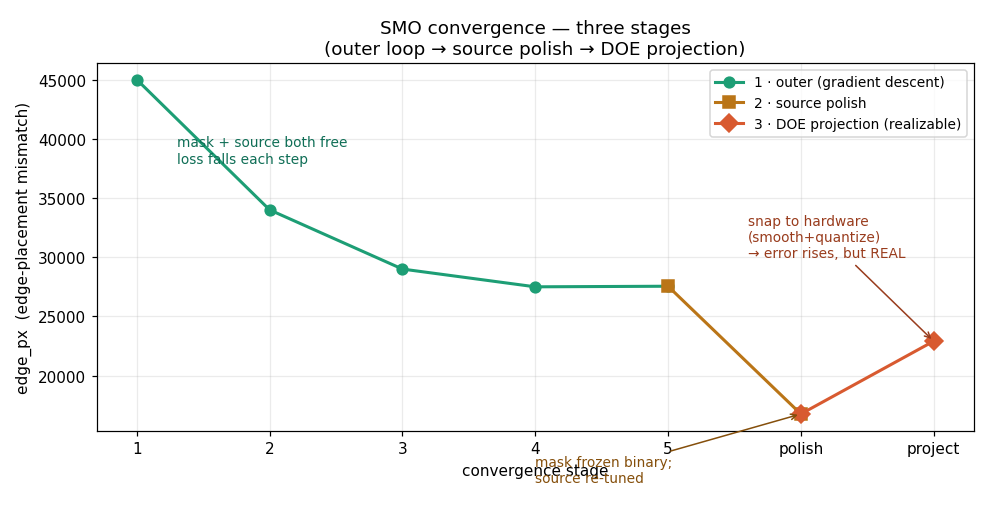

1. **outer  (the gradient-descent loop)**

> Each `outer` point is one full alternating SMO iteration: a **mask step** (fix source,
descend the mask = OPC/ILT) then a **source step** (fix mask, optimize the DOE weights).
Both mask and source are free. The plotted loss is `pattern_error` (MSE printed-vs-
target) and it should fall from iteration 1 toward N. **This is the true optimization**
— `everything after is manufacturability cleanup.`

2. **source polish  (`phase='polish'`)**
After the loop, the mask is frozen to a binary, MRC-cleaned pattern. That hard step nudges the image off the smooth optimum, so the **source polish** re-optimizes *only*
the DOE weights against the fixed mask, letting the illumination absorb some of the binarization damage. Expect a partial recovery of edge error.

3. DOE projection  (`phase='doe_project'`)
The final step makes the *source* buildable: k-space smoothing (kill spikes) then quantization to a few discrete levels (2 = binary aperture, more = mirror-array). This forces the ideal continuous DOE onto hardware-legal shapes, so edge error typically **rises** — the small, honest price of manufacturability. **This last point is the realizable result**: the print you'd actually get on a real tool.

**Reading the curve in one line**
- Descend to a good ideal solution (outer, error falls) → freeze and clean the mask,
- recover with a source-only polish (error dips back) →
- snap the source onto real hardware (error rises to its realizable value).

The green→amber→coral progression is
*ideal optimum → recovered → manufacturable*, and the final coral point is the number that actually matters.